# Step 1 — Import libraries and load the datasets

In [ ]:
import pandas as pd

# Load the datasets
transactions = pd.read_csv("train_transaction.csv")
identity = pd.read_csv("train_identity.csv")

# Check dataset sizes
print("Transactions shape:", transactions.shape)
print("Identity shape:", identity.shape)

Transactions shape: (292590, 394)
Identity shape: (144233, 41)


In [ ]:
transactions.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


# Step 2 — Merge transaction and identity datasets

In [ ]:
data = pd.merge(
    transactions,
    identity,
    on="TransactionID",
    how="left"
)

print("Merged dataset shape:", data.shape)
data.head()

Merged dataset shape: (292590, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


# Step 3 — Check fraud distribution

In [ ]:
print(data["isFraud"].value_counts())

print("\nFraud percentage:")
print(data["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    282791
1      9799
Name: count, dtype: int64

Fraud percentage:
isFraud
0    96.650945
1     3.349055
Name: proportion, dtype: float64


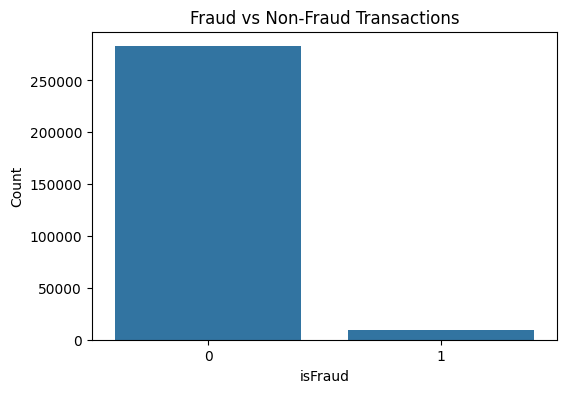

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=data)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")

plt.show()

# Step 4 — Check missing values

In [ ]:
missing_percent = data.isnull().mean() * 100

missing_percent.sort_values(ascending=False).head(20)

,0
id_24,98.999624
id_25,98.919990
id_07,98.917598
id_08,98.917598
id_21,98.916573
id_26,98.915547
id_27,98.915206
id_22,98.915206
id_23,98.915206
D7,93.548310


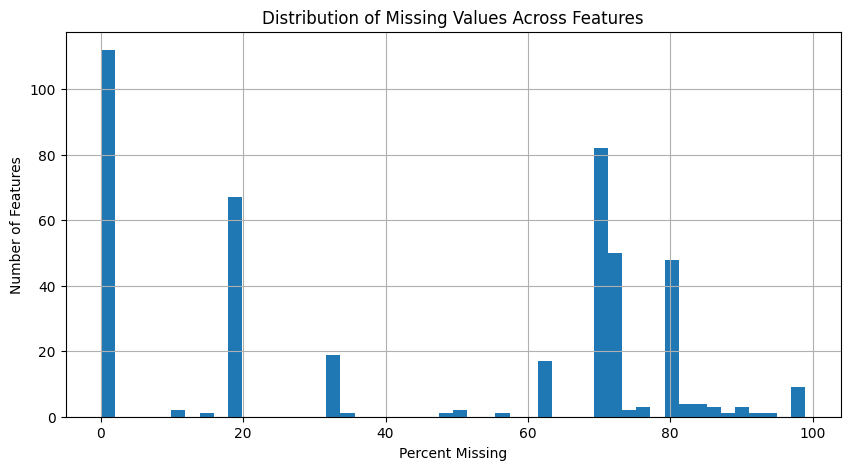

In [ ]:
# Visualize missing value distribution

plt.figure(figsize=(10,5))

missing_percent.hist(bins=50)

plt.title("Distribution of Missing Values Across Features")
plt.xlabel("Percent Missing")
plt.ylabel("Number of Features")

plt.show()

# Step 5 — Drop columns with more than 70% missing values

In [ ]:
cols_to_drop = missing_percent[missing_percent > 70].index

print("Number of columns to drop:", len(cols_to_drop))

data = data.drop(columns=cols_to_drop)

print("New dataset shape:", data.shape)

Number of columns to drop: 211
New dataset shape: (292590, 223)


In [ ]:
# Show some of the dropped columns
list(cols_to_drop)[:20]

['dist2',
 'R_emaildomain',
 'D6',
 'D7',
 'D8',
 'D9',
 'D12',
 'D13',
 'D14',
 'M7',
 'M8',
 'M9',
 'V138',
 'V139',
 'V140',
 'V141',
 'V142',
 'V143',
 'V144',
 'V145']

# Step 6 — Check remaining missing values


In [ ]:
missing_percent_after = data.isnull().mean() * 100

missing_percent_after.sort_values(ascending=False).head(20)

,0
V6,63.122800
V7,63.122800
V1,63.122800
V9,63.122800
V10,63.122800
V11,63.122800
V8,63.122800
V5,63.122800
V3,63.122800
V2,63.122800


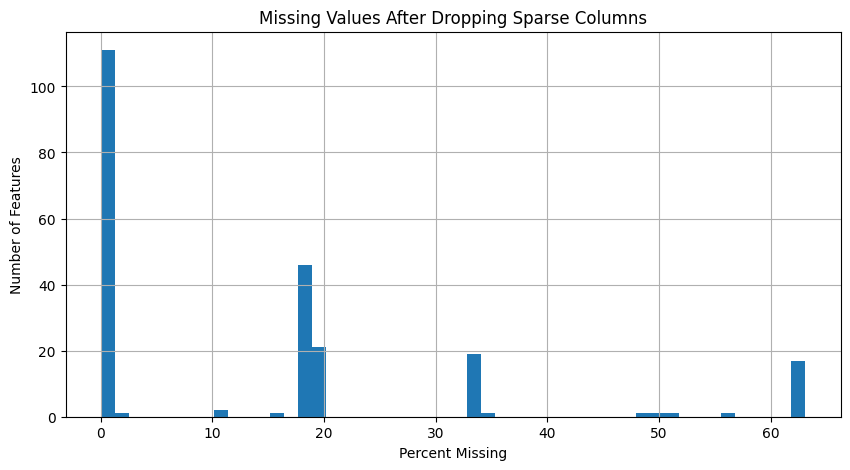

In [ ]:
plt.figure(figsize=(10,5))

missing_percent_after.hist(bins=50)

plt.title("Missing Values After Dropping Sparse Columns")
plt.xlabel("Percent Missing")
plt.ylabel("Number of Features")

plt.show()

# Step 7 — Fill remaining missing values

In [ ]:
for col in data.columns:

    if data[col].dtype == "object":
        # Categorical → fill with mode
        data[col] = data[col].fillna(data[col].mode()[0])

    else:
        # Numeric → fill with median
        data[col] = data[col].fillna(data[col].median())

In [ ]:
# Check if any missing values remain
data.isnull().sum().sum()

np.int64(0)

In [ ]:
data = data.copy()

# EDA Step

**Transaction Amount Distribution**

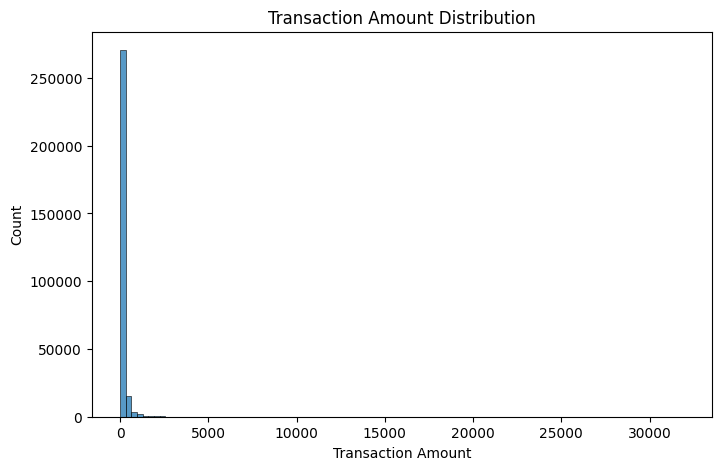

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(data["TransactionAmt"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

plt.show()

**EDA Step — Fraud vs Non-Fraud Transaction Amount**


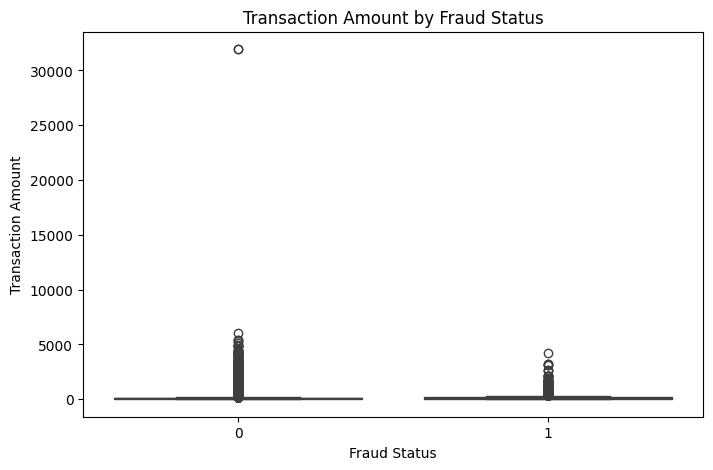

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="isFraud",
    y="TransactionAmt",
    data=data
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")

plt.show()

**EDA Step — Fraud by Product Type**

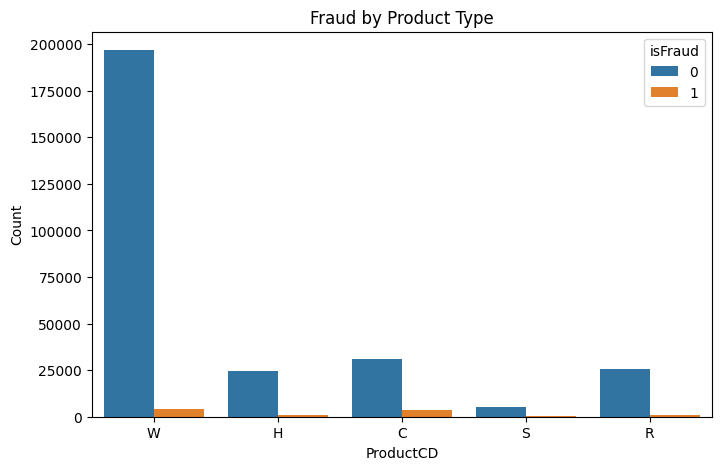

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="ProductCD",
    hue="isFraud",
    data=data
)

plt.title("Fraud by Product Type")
plt.xlabel("ProductCD")
plt.ylabel("Count")

plt.show()

**EDA Step — Features Most Correlated with Fraud**

In [ ]:
corr = data.corr(numeric_only=True)

fraud_corr = corr["isFraud"].sort_values(ascending=False)

fraud_corr.head(15)

,isFraud
isFraud,1.000000
V45,0.222562
V87,0.216086
V86,0.211280
V44,0.201903
V52,0.180578
V51,0.164993
V79,0.158882
V40,0.151732
V38,0.150612


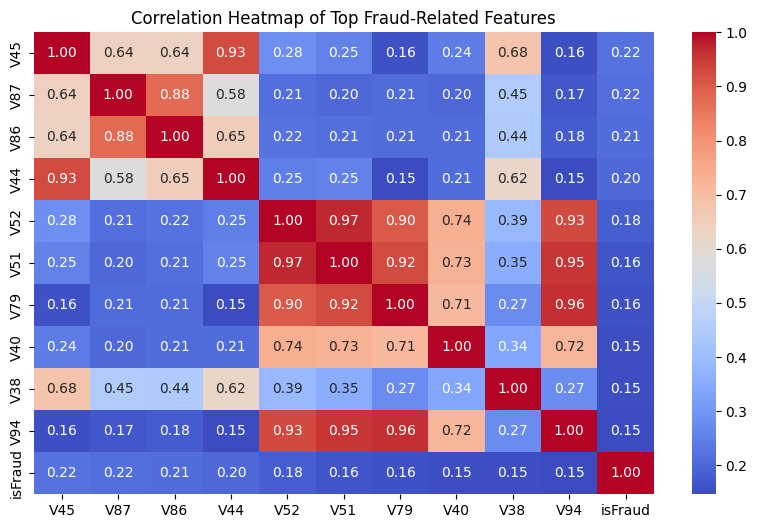

In [ ]:
# EDA Step — Heatmap of Top Features Correlated with Fraud

import seaborn as sns
import matplotlib.pyplot as plt

# Select top 10 correlated features (excluding isFraud itself)
top_features = fraud_corr.index[1:11]

# Create correlation matrix for those features
corr_matrix = data[top_features.tolist() + ["isFraud"]].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Fraud-Related Features")

plt.show()

**EDA Step — Fraud Rate by Transaction Amount Buckets**

/tmp/ipykernel_7100/2240851738.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_amount = data.groupby("AmountBin")["isFraud"].mean()


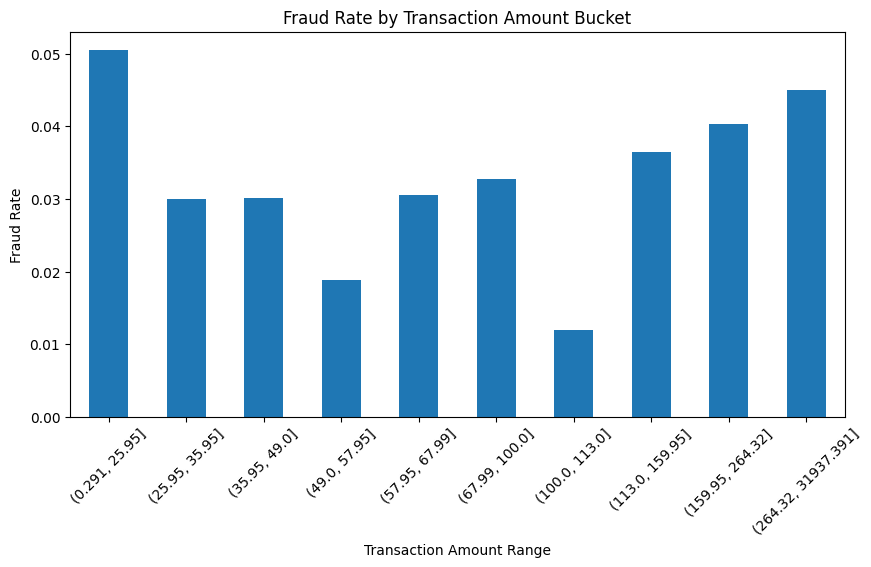

In [ ]:
# Create amount bins
data["AmountBin"] = pd.qcut(data["TransactionAmt"], q=10)

fraud_by_amount = data.groupby("AmountBin")["isFraud"].mean()

plt.figure(figsize=(10,5))

fraud_by_amount.plot(kind="bar")

plt.title("Fraud Rate by Transaction Amount Bucket")
plt.xlabel("Transaction Amount Range")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

**EDA Step — Fraud Rate by Card Network**

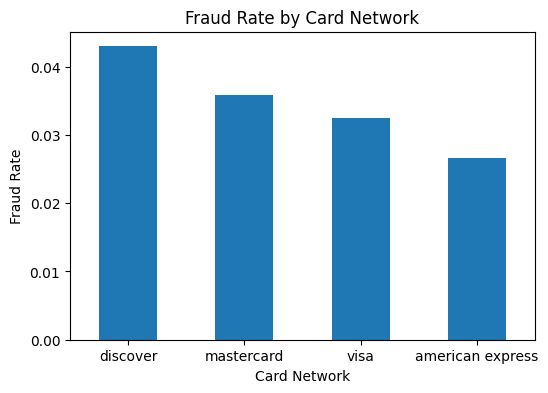

In [ ]:
fraud_card = data.groupby("card4")["isFraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
fraud_card.plot(kind="bar")

plt.title("Fraud Rate by Card Network")
plt.xlabel("Card Network")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=0)
plt.show()

**EDA Step — Fraud Rate by Email Domain**

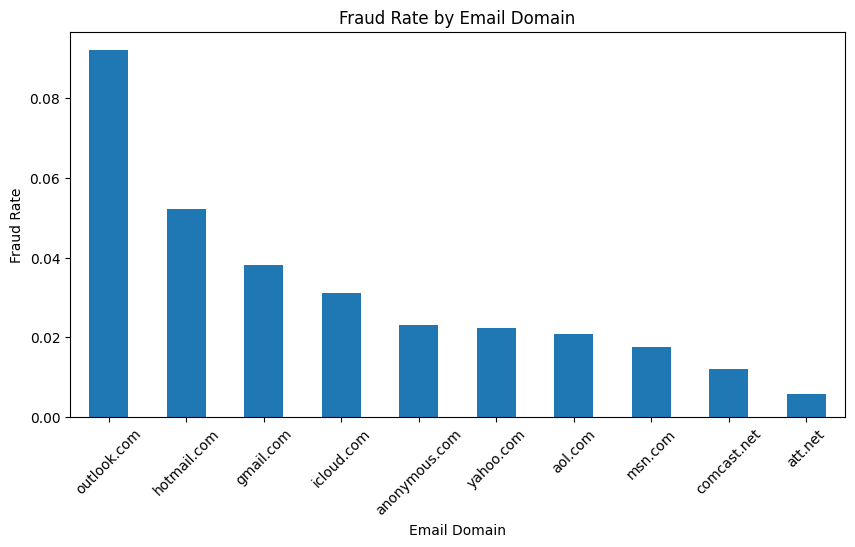

In [ ]:
top_domains = data["P_emaildomain"].value_counts().head(10).index

subset = data[data["P_emaildomain"].isin(top_domains)]

fraud_email = subset.groupby("P_emaildomain")["isFraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
fraud_email.plot(kind="bar")

plt.title("Fraud Rate by Email Domain")
plt.xlabel("Email Domain")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)
plt.show()

# Step 8 — Prepare Data for Modeling

**8.1 Drop non-useful columns**

In [ ]:
# Step 8.1 — Drop non-useful columns

data = data.drop(columns=["TransactionID", "AmountBin"], errors="ignore")

print("New dataset shape:", data.shape)

New dataset shape: (292590, 222)


**Step 8.2 Separate Features and Target**

In [ ]:
# Step 8.2 — Separate features and target

X = data.drop("isFraud", axis=1)
y = data["isFraud"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (292590, 221)
Target shape: (292590,)


**Step 8.3 Encode Categorical Variables**

In [ ]:
# Step 8.3 — One-hot encode categorical variables

X = pd.get_dummies(X, drop_first=True)

print("New feature shape after encoding:", X.shape)

New feature shape after encoding: (292590, 286)


**Step 8.4 Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# Step 8.4 — Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (234072, 286)
Test set: (58518, 286)


# Step 9 — Feature Scaling

In [ ]:
# Step 9 — Feature Scaling for sampled models

from sklearn.preprocessing import StandardScaler

# Take smaller samples for models that need scaling
X_train_small = X_train.sample(n=100000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

X_test_small = X_test.sample(n=30000, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

# Scale the sampled data
scaler = StandardScaler()

X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)

print("Sampled training set:", X_train_small.shape)
print("Sampled test set:", X_test_small.shape)
print("Scaled training shape:", X_train_small_scaled.shape)
print("Scaled test shape:", X_test_small_scaled.shape)

Sampled training set: (100000, 286)
Sampled test set: (30000, 286)
Scaled training shape: (100000, 286)
Scaled test shape: (30000, 286)


# Step 10 — Baseline Model (Logistic Regression)

In [ ]:
# Step 10 — Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train baseline model
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_small_scaled, y_train_small)

# Predictions
y_pred = log_model.predict(X_test_small_scaled)
y_prob = log_model.predict_proba(X_test_small_scaled)[:,1]

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test_small, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_small, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test_small, y_prob))

Confusion Matrix:
[[28952    46]
 [  820   182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     28998
           1       0.80      0.18      0.30      1002

    accuracy                           0.97     30000
   macro avg       0.89      0.59      0.64     30000
weighted avg       0.97      0.97      0.96     30000


ROC-AUC Score: 0.8409895843873326


<Figure size 600x500 with 0 Axes>

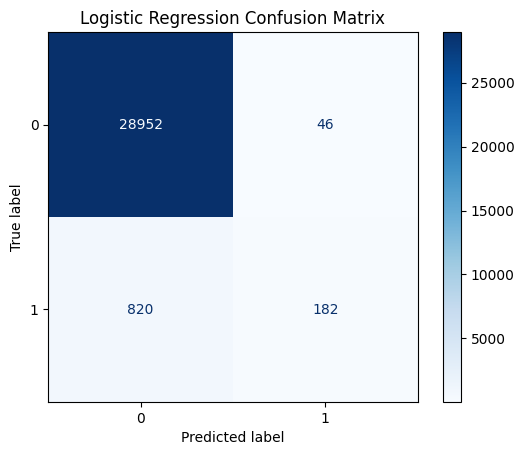

In [ ]:
# Visualization — Logistic Regression Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test_small,
    y_pred,
    cmap="Blues",
    values_format="d"
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

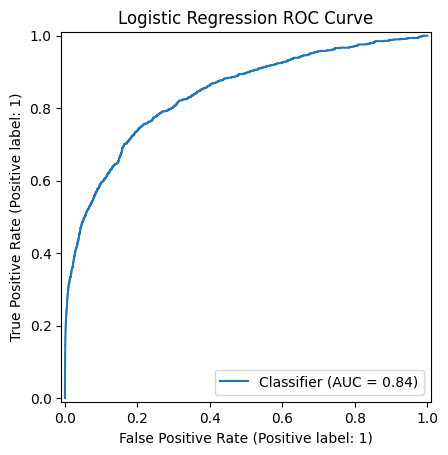

In [ ]:
# Visualization — Logistic Regression ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test_small, y_prob)
plt.title("Logistic Regression ROC Curve")
plt.show()

# Step 11 — Simple Models

**Decison Tree**

In [ ]:
# Step 11 — Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print("Decision Tree Results\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_dt))

Decision Tree Results

Confusion Matrix:
[[55629   929]
 [  800  1160]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     56558
           1       0.56      0.59      0.57      1960

    accuracy                           0.97     58518
   macro avg       0.77      0.79      0.78     58518
weighted avg       0.97      0.97      0.97     58518


ROC-AUC Score: 0.7877055592561294


<Figure size 600x500 with 0 Axes>

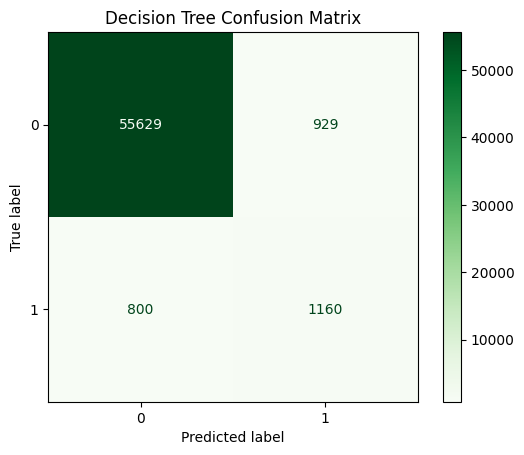

In [ ]:
# Visualization — Decision Tree Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Greens",
    values_format="d"
)
plt.title("Decision Tree Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

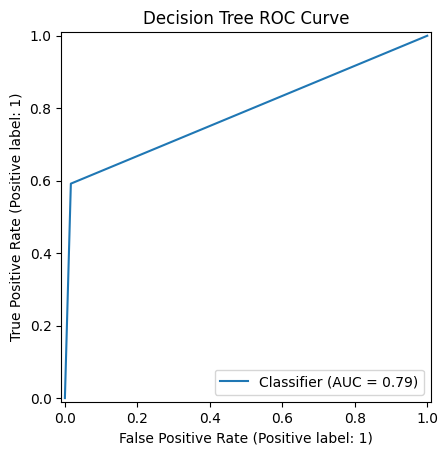

In [ ]:
# Visualization — Decision Tree ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_dt)
plt.title("Decision Tree ROC Curve")
plt.show()

**Naive Bayes**

In [ ]:
# Step 11 — Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_small_scaled, y_train_small)

y_pred_nb = nb_model.predict(X_test_small_scaled)
y_prob_nb = nb_model.predict_proba(X_test_small_scaled)[:,1]

print("Naive Bayes Results\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_small, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test_small, y_pred_nb))

print("\nROC-AUC Score:", roc_auc_score(y_test_small, y_prob_nb))

Naive Bayes Results

Confusion Matrix:
[[ 1298 27700]
 [   11   991]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.04      0.09     28998
           1       0.03      0.99      0.07      1002

    accuracy                           0.08     30000
   macro avg       0.51      0.52      0.08     30000
weighted avg       0.96      0.08      0.09     30000


ROC-AUC Score: 0.5177256873245715


<Figure size 600x500 with 0 Axes>

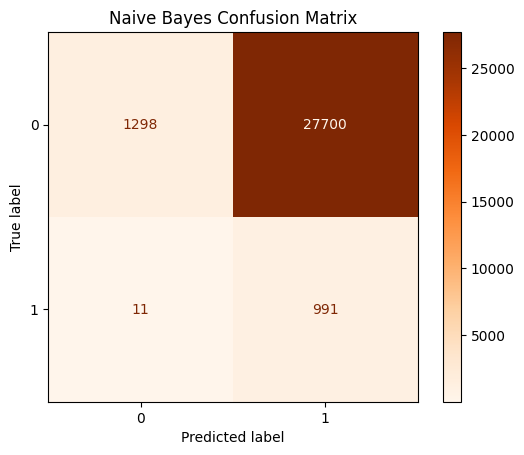

In [ ]:
# Visualization — Naive Bayes Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test_small,
    y_pred_nb,
    cmap="Oranges",
    values_format="d"
)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

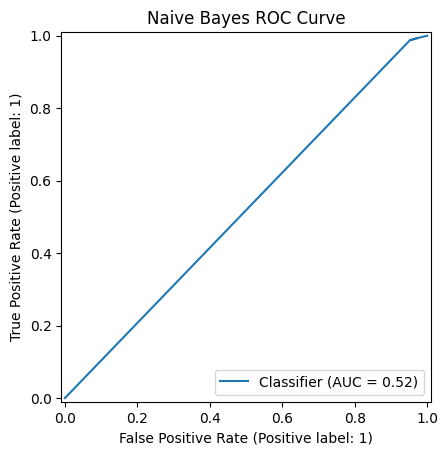

In [ ]:
# Visualization — Naive Bayes ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test_small, y_prob_nb)
plt.title("Naive Bayes ROC Curve")
plt.show()

# Step 12 - Complex Models

**Random Forest**

In [ ]:
# Step 12 — Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results

Confusion Matrix:
[[56498    60]
 [ 1023   937]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.94      0.48      0.63      1960

    accuracy                           0.98     58518
   macro avg       0.96      0.74      0.81     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC Score: 0.9248684527207396


<Figure size 600x500 with 0 Axes>

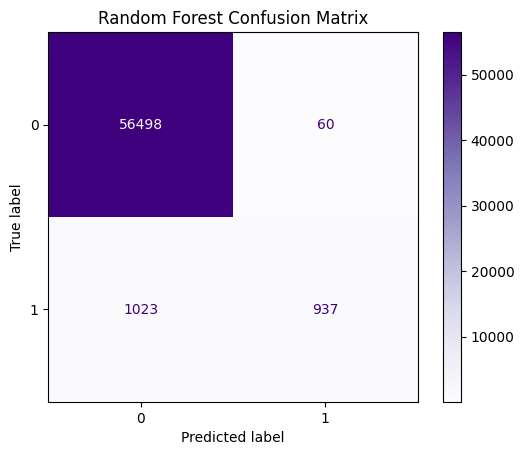

In [ ]:
# Visualization — Random Forest Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Purples",
    values_format="d"
)
plt.title("Random Forest Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

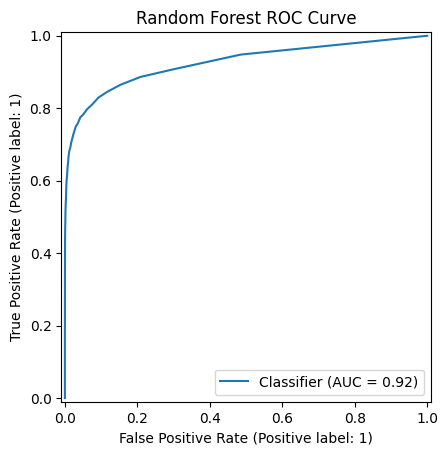

In [ ]:
# Visualization — Random Forest ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("Random Forest ROC Curve")
plt.show()

**XGBoost**

In [ ]:
# Step 12 — XGBoost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("XGBoost Results\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results

Confusion Matrix:
[[56484    74]
 [  983   977]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.93      0.50      0.65      1960

    accuracy                           0.98     58518
   macro avg       0.96      0.75      0.82     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC Score: 0.9408476786697563


<Figure size 600x500 with 0 Axes>

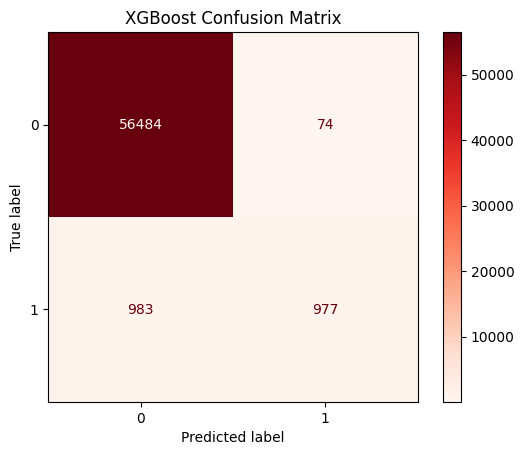

In [ ]:
# Visualization — XGBoost Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Reds",
    values_format="d"
)
plt.title("XGBoost Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

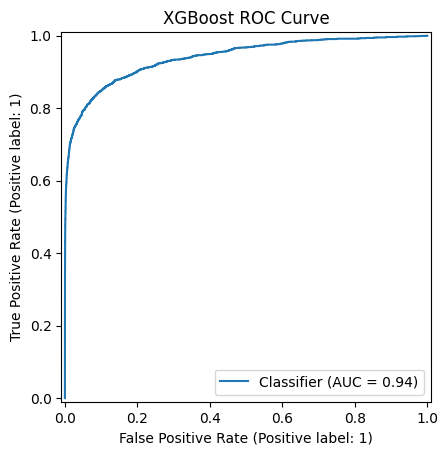

In [ ]:
# Visualization — XGBoost ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("XGBoost ROC Curve")
plt.show()

**Neural Network**

In [ ]:
# Step 12 — Neural Network

from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=20,
    random_state=42
)

nn_model.fit(X_train_small_scaled, y_train_small)

y_pred_nn = nn_model.predict(X_test_small_scaled)
y_prob_nn = nn_model.predict_proba(X_test_small_scaled)[:,1]

print("Neural Network Results\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test_small, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test_small, y_pred_nn))

print("\nROC-AUC Score:", roc_auc_score(y_test_small, y_prob_nn))

Neural Network Results

Confusion Matrix:
[[28903    95]
 [  591   411]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     28998
           1       0.81      0.41      0.55      1002

    accuracy                           0.98     30000
   macro avg       0.90      0.70      0.77     30000
weighted avg       0.97      0.98      0.97     30000


ROC-AUC Score: 0.8775157113870748


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


<Figure size 600x500 with 0 Axes>

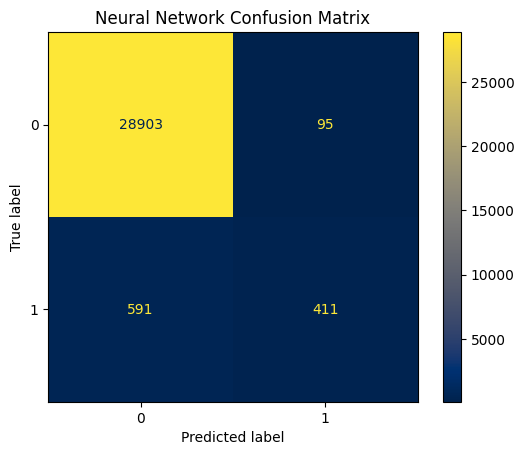

In [ ]:
# Visualization — Neural Network Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test_small,
    y_pred_nn,
    cmap="cividis",
    values_format="d"
)
plt.title("Neural Network Confusion Matrix")
plt.show()

<Figure size 600x500 with 0 Axes>

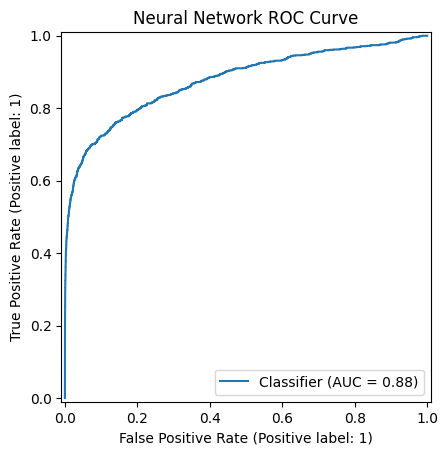

In [ ]:
# Visualization — Neural Network ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test_small, y_prob_nn)
plt.title("Neural Network ROC Curve")
plt.show()

# All Models ROC Curve Comparison & Model Performance Comparison Graph

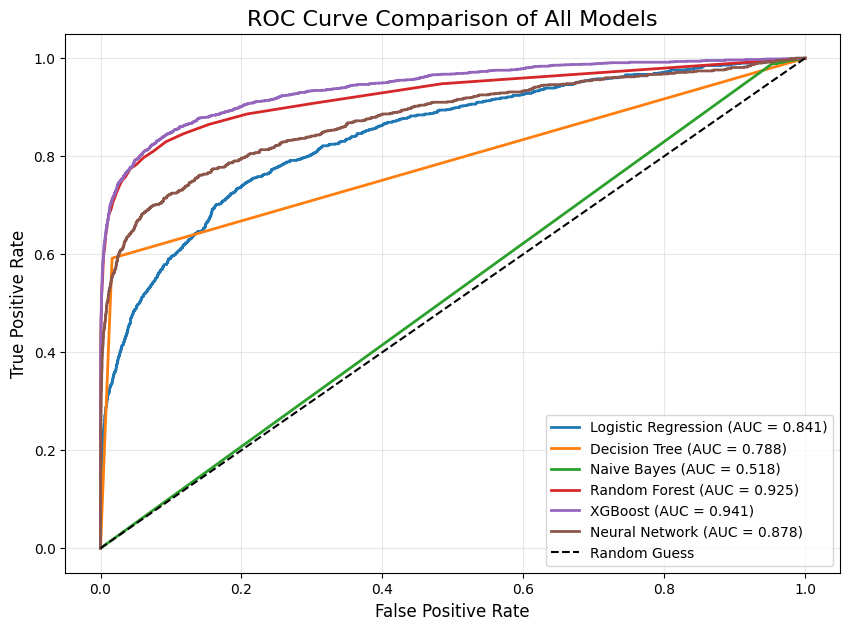

In [ ]:
# Visualization — ROC Curve Comparison for All Models

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test_small, y_prob)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, linewidth=2, label=f"Logistic Regression (AUC = {auc_log:.3f})")

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f"Decision Tree (AUC = {auc_dt:.3f})")

# Naive Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test_small, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, linewidth=2, label=f"Naive Bayes (AUC = {auc_nb:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f"Random Forest (AUC = {auc_rf:.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, linewidth=2, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_test_small, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, linewidth=2, label=f"Neural Network (AUC = {auc_nn:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="black", label="Random Guess")

plt.title("ROC Curve Comparison of All Models", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

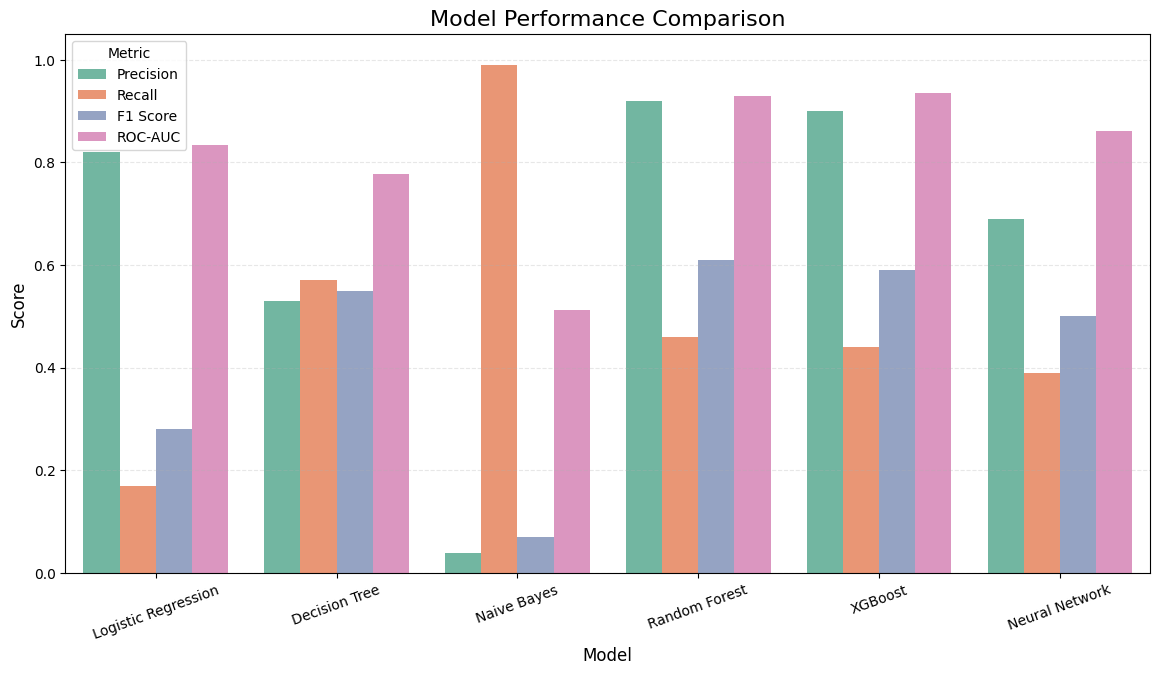

In [ ]:
# Visualization — Model Performance Comparison

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Build comparison table using your actual results
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Naive Bayes",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "Precision": [0.82, 0.53, 0.04, 0.92, 0.90, 0.69],
    "Recall":    [0.17, 0.57, 0.99, 0.46, 0.44, 0.39],
    "F1 Score":  [0.28, 0.55, 0.07, 0.61, 0.59, 0.50],
    "ROC-AUC":   [0.833, 0.778, 0.513, 0.930, 0.936, 0.861]
})

comparison_long = comparison_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title("Model Performance Comparison", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

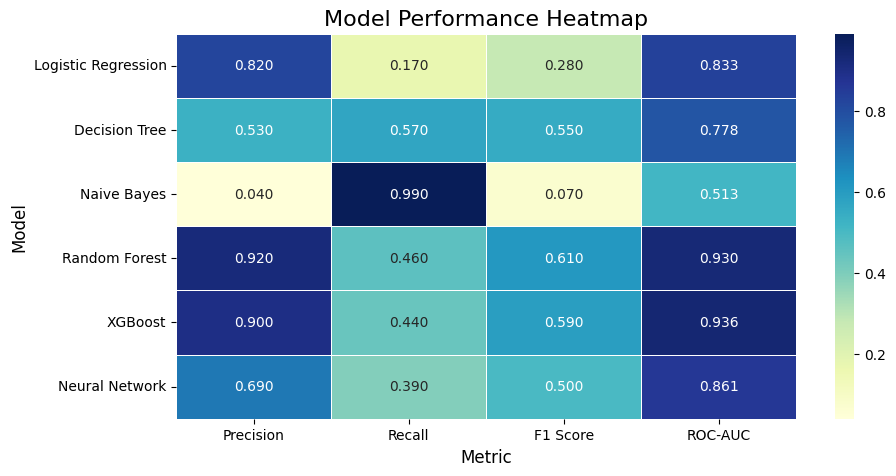

In [ ]:
# Visualization — Performance Heatmap

plt.figure(figsize=(10, 5))

heatmap_data = comparison_df.set_index("Model")

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
    linewidths=0.5
)

plt.title("Model Performance Heatmap", fontsize=16)
plt.xlabel("Metric", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.show()

# Step 13 — Handle Class Imbalance For Top 2 Models (Random Forest)

**Step 13.1 — Random Oversampling**

In [ ]:
# Step 13.1 — Random Oversampling

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Original class distribution:")
print(y_train.value_counts())

print("\nOversampled class distribution:")
print(y_train_ros.value_counts())

Original class distribution:
isFraud
0    226233
1      7839
Name: count, dtype: int64

Oversampled class distribution:
isFraud
0    226233
1    226233
Name: count, dtype: int64


**Step 13.1.1 — Train Random Forest with Oversampling**

In [ ]:
# Step 13.1.1 — Random Forest with Random Oversampling

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_ros = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_ros.fit(X_train_ros, y_train_ros)

y_pred_rf_ros = rf_ros.predict(X_test)
y_prob_rf_ros = rf_ros.predict_proba(X_test)[:, 1]

print("Random Forest + Random Oversampling\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_ros))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_ros))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf_ros))

Random Forest + Random Oversampling

Confusion Matrix:
[[56448   110]
 [  925  1035]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.90      0.53      0.67      1960

    accuracy                           0.98     58518
   macro avg       0.94      0.76      0.83     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC Score: 0.9343968373445067


**Step 13.1.2 — Visualizations for Random Forest + Oversampling
Confusion Matrix**

<Figure size 600x500 with 0 Axes>

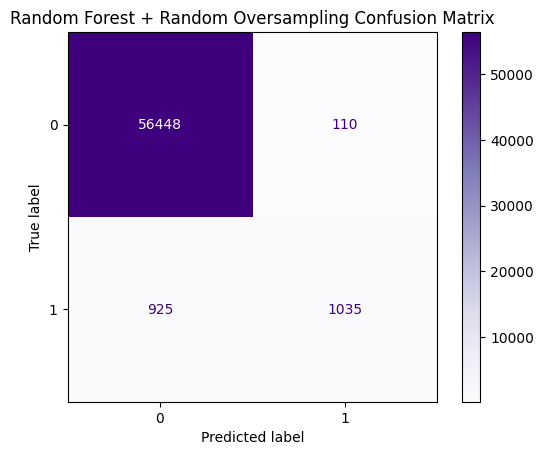

In [ ]:
# Visualization — Random Forest + Oversampling Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_ros,
    cmap="Purples",
    values_format="d"
)
plt.title("Random Forest + Random Oversampling Confusion Matrix")
plt.show()

**ROC Curve**

<Figure size 600x500 with 0 Axes>

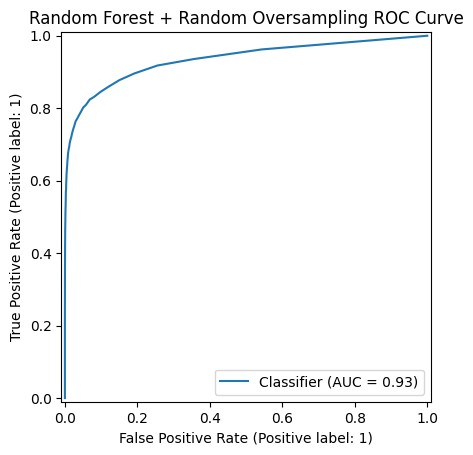

In [ ]:
# Visualization — Random Forest + Oversampling ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_rf_ros)
plt.title("Random Forest + Random Oversampling ROC Curve")
plt.show()

**Step 13.2 — SMOTE**

In [ ]:
# Step 13.2 — SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE class distribution:")
print(y_train_smote.value_counts())

SMOTE class distribution:
isFraud
0    226233
1    226233
Name: count, dtype: int64


**Train Random Forest with SMOTE**

In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)
y_prob_rf_smote = rf_smote.predict_proba(X_test)[:,1]

**Evaluate SMOTE Model**

In [ ]:
print("Random Forest + SMOTE\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_smote))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))

Random Forest + SMOTE

Confusion Matrix:
[[56468    90]
 [ 1007   953]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.91      0.49      0.63      1960

    accuracy                           0.98     58518
   macro avg       0.95      0.74      0.81     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC: 0.9125649504824738


**Random Forest + SMOTE — Confusion Matrix**

<Figure size 600x500 with 0 Axes>

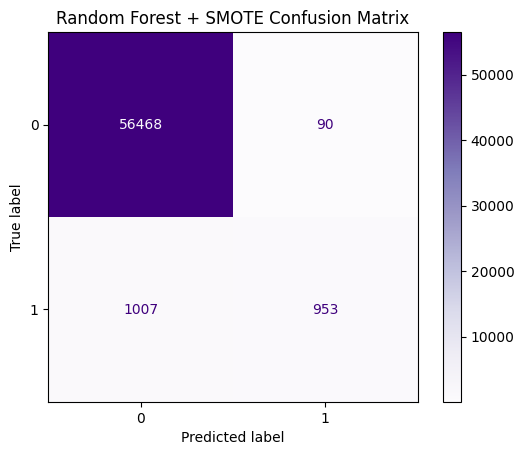

In [ ]:
# Visualization — Random Forest + SMOTE Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_smote,
    cmap="Purples",
    values_format="d"
)

plt.title("Random Forest + SMOTE Confusion Matrix")
plt.show()

**Random Forest + SMOTE — ROC Curve**

<Figure size 600x500 with 0 Axes>

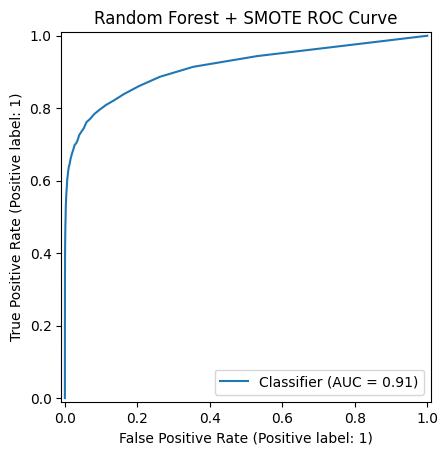

In [ ]:
# Visualization — Random Forest + SMOTE ROC Curve

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf_smote
)

plt.title("Random Forest + SMOTE ROC Curve")
plt.show()

**Step 13.3 — ADASYN**

In [ ]:
# Step 13.3 — ADASYN

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("ADASYN class distribution:")
print(y_train_adasyn.value_counts())

ADASYN class distribution:
isFraud
0    226233
1    225182
Name: count, dtype: int64


**Train Random Forest with ADASYN**

In [ ]:
rf_adasyn = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_rf_adasyn = rf_adasyn.predict(X_test)
y_prob_rf_adasyn = rf_adasyn.predict_proba(X_test)[:,1]

**Evaluate ADASYN Model**

In [ ]:
print("Random Forest + ADASYN\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_adasyn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_adasyn))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf_adasyn))

Random Forest + ADASYN

Confusion Matrix:
[[56470    88]
 [  994   966]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.92      0.49      0.64      1960

    accuracy                           0.98     58518
   macro avg       0.95      0.75      0.82     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC: 0.9149254720276314


**Confusion Matrix:**

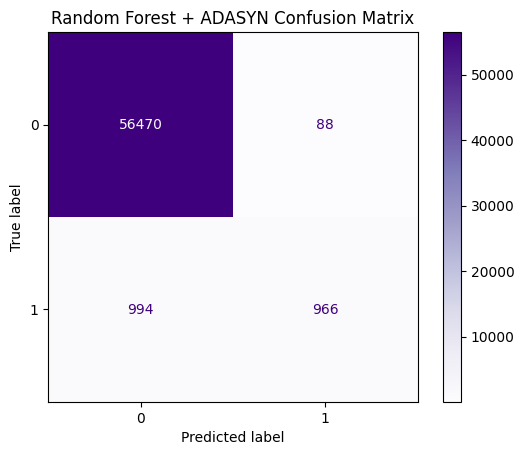

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_adasyn,
    cmap="Purples",
    values_format="d"
)
plt.title("Random Forest + ADASYN Confusion Matrix")
plt.show()

**ROC Curve:**

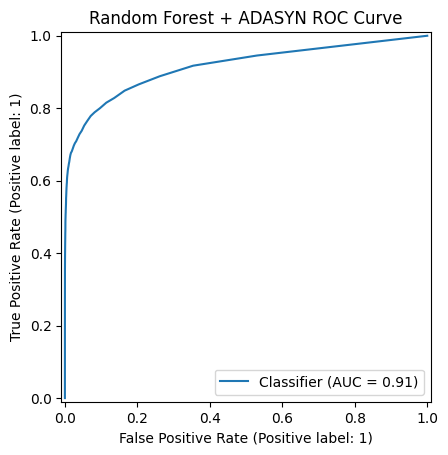

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf_adasyn)
plt.title("Random Forest + ADASYN ROC Curve")
plt.show()

# Step 14 — Handle Class Imbalance For Top 2 Models (XGBoost)

**Step 14 — XGBoost + Oversampling**

In [ ]:
# Step 14 — Train XGBoost with Random Oversampling

from xgboost import XGBClassifier

xgb_ros = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_ros.fit(X_train_ros, y_train_ros)

y_pred_xgb_ros = xgb_ros.predict(X_test)
y_prob_xgb_ros = xgb_ros.predict_proba(X_test)[:,1]

**Evaluate the Model**

In [ ]:
print("XGBoost + Random Oversampling\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_ros))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_ros))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb_ros))

XGBoost + Random Oversampling

Confusion Matrix:
[[52669  3889]
 [  370  1590]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     56558
           1       0.29      0.81      0.43      1960

    accuracy                           0.93     58518
   macro avg       0.64      0.87      0.69     58518
weighted avg       0.97      0.93      0.94     58518


ROC-AUC: 0.9417301617772185


**Visualizations
Confusion Matrix**

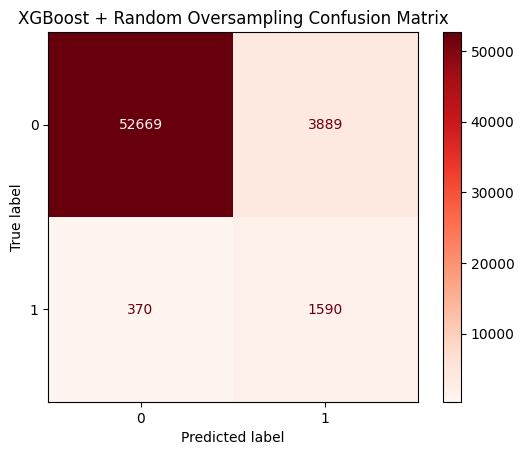

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_ros,
    cmap="Reds",
    values_format="d"
)

plt.title("XGBoost + Random Oversampling Confusion Matrix")
plt.show()

**ROC Curve**

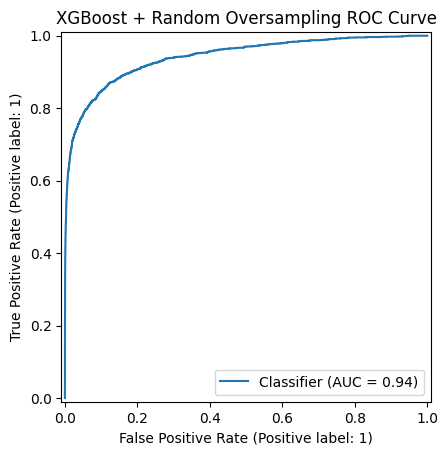

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb_ros
)

plt.title("XGBoost + Random Oversampling ROC Curve")
plt.show()

**XGBoost + SMOTE**

In [ ]:
# Step 14 – Train XGBoost with SMOTE

from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

**Evaluate the Model**

In [ ]:
# Evaluate the Model

print("XGBoost + SMOTE\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_smote))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb_smote))

XGBoost + SMOTE

Confusion Matrix:
[[56433   125]
 [  995   965]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.89      0.49      0.63      1960

    accuracy                           0.98     58518
   macro avg       0.93      0.75      0.81     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC: 0.9242686801195955


**Confusion Matrix Visualization**

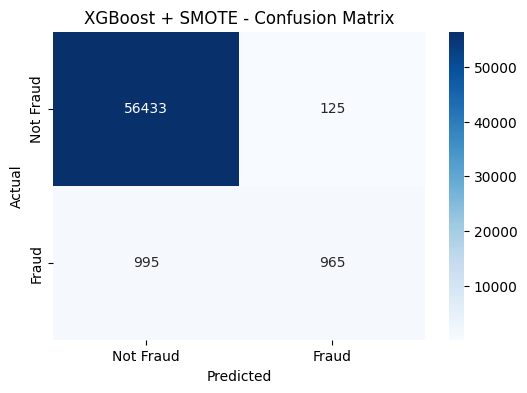

In [ ]:
# Confusion Matrix Visualization

cm_xgb_smote = confusion_matrix(y_test, y_pred_xgb_smote)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title("XGBoost + SMOTE - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve Visualization**

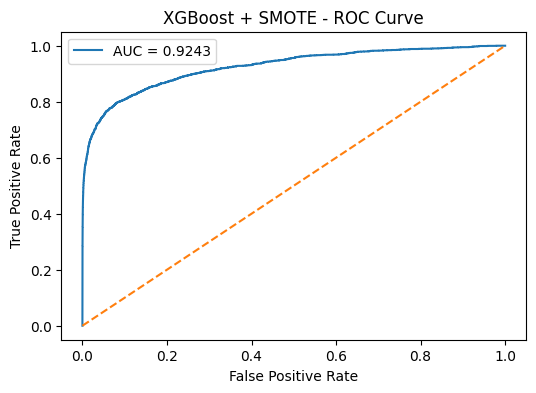

In [ ]:
# ROC Curve Visualization

fpr_xgb_smote, tpr_xgb_smote, _ = roc_curve(y_test, y_prob_xgb_smote)
roc_auc_xgb_smote = roc_auc_score(y_test, y_prob_xgb_smote)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb_smote, tpr_xgb_smote, label=f"AUC = {roc_auc_xgb_smote:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("XGBoost + SMOTE - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**XGBoost + ADASYN**

In [ ]:
# Step 14 – Train XGBoost with ADASYN

from xgboost import XGBClassifier

xgb_adasyn = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_pred_xgb_adasyn = xgb_adasyn.predict(X_test)
y_prob_xgb_adasyn = xgb_adasyn.predict_proba(X_test)[:, 1]

**Evaluate the Model**

In [ ]:
# Evaluate the Model

print("XGBoost + ADASYN\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_adasyn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_adasyn))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_xgb_adasyn))

XGBoost + ADASYN

Confusion Matrix:
[[56442   116]
 [  974   986]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56558
           1       0.89      0.50      0.64      1960

    accuracy                           0.98     58518
   macro avg       0.94      0.75      0.82     58518
weighted avg       0.98      0.98      0.98     58518


ROC-AUC: 0.9272191008904711


**Confusion Matrix Visualization**

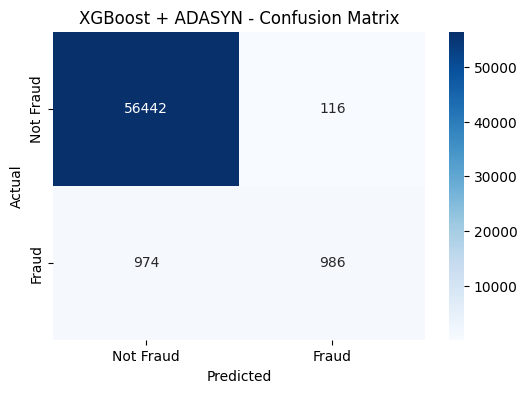

In [ ]:
# Confusion Matrix Visualization

cm_xgb_adasyn = confusion_matrix(y_test, y_pred_xgb_adasyn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb_adasyn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title("XGBoost + ADASYN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve Visualization**

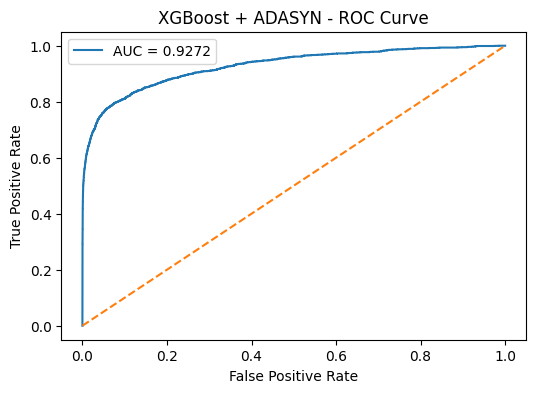

In [ ]:
# ROC Curve Visualization

fpr_xgb_adasyn, tpr_xgb_adasyn, _ = roc_curve(y_test, y_prob_xgb_adasyn)
roc_auc_xgb_adasyn = roc_auc_score(y_test, y_prob_xgb_adasyn)

plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb_adasyn, tpr_xgb_adasyn, label=f"AUC = {roc_auc_xgb_adasyn:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("XGBoost + ADASYN - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Final Comparison Graph

**Block 1 — Build comparison table for updated top models**

In [ ]:
# Import evaluation metrics

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [ ]:
# Step 15 – Compare Top Models Before and After Imbalance Techniques

comparison_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "RF + Random Oversampling",
        "RF + SMOTE",
        "RF + ADASYN",
        "XGBoost + Random Oversampling",
        "XGBoost + SMOTE",
        "XGBoost + ADASYN"
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_rf_ros),
        precision_score(y_test, y_pred_rf_smote),
        precision_score(y_test, y_pred_rf_adasyn),
        precision_score(y_test, y_pred_xgb_ros),
        precision_score(y_test, y_pred_xgb_smote),
        precision_score(y_test, y_pred_xgb_adasyn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_rf_ros),
        recall_score(y_test, y_pred_rf_smote),
        recall_score(y_test, y_pred_rf_adasyn),
        recall_score(y_test, y_pred_xgb_ros),
        recall_score(y_test, y_pred_xgb_smote),
        recall_score(y_test, y_pred_xgb_adasyn)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_rf_ros),
        f1_score(y_test, y_pred_rf_smote),
        f1_score(y_test, y_pred_rf_adasyn),
        f1_score(y_test, y_pred_xgb_ros),
        f1_score(y_test, y_pred_xgb_smote),
        f1_score(y_test, y_pred_xgb_adasyn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_rf_ros),
        roc_auc_score(y_test, y_prob_rf_smote),
        roc_auc_score(y_test, y_prob_rf_adasyn),
        roc_auc_score(y_test, y_prob_xgb_ros),
        roc_auc_score(y_test, y_prob_xgb_smote),
        roc_auc_score(y_test, y_prob_xgb_adasyn)
    ]
})

comparison_results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.939819,0.478061,0.633750,0.924868
1,XGBoost,0.929591,0.498469,0.648954,0.940848
2,RF + Random Oversampling,0.903930,0.528061,0.666667,0.934397
3,RF + SMOTE,0.913710,0.486224,0.634699,0.912565
4,RF + ADASYN,0.916509,0.492857,0.641009,0.914925
5,XGBoost + Random Oversampling,0.290199,0.811224,0.427477,0.941730
6,XGBoost + SMOTE,0.885321,0.492347,0.632787,0.924269
7,XGBoost + ADASYN,0.894737,0.503061,0.644024,0.927219


**Block 2 — Display rounded comparison table**

In [ ]:
# Rounded Comparison Table

comparison_results_rounded = comparison_results.copy()
comparison_results_rounded[["Precision", "Recall", "F1-Score", "ROC-AUC"]] = comparison_results_rounded[
    ["Precision", "Recall", "F1-Score", "ROC-AUC"]
].round(4)

print("Comparison of Top Models Before and After Imbalance Techniques:\n")
print(comparison_results_rounded)

Comparison of Top Models Before and After Imbalance Techniques:

                           Model  Precision  Recall  F1-Score  ROC-AUC
0                  Random Forest     0.9398  0.4781    0.6338   0.9249
1                        XGBoost     0.9296  0.4985    0.6490   0.9408
2       RF + Random Oversampling     0.9039  0.5281    0.6667   0.9344
3                     RF + SMOTE     0.9137  0.4862    0.6347   0.9126
4                    RF + ADASYN     0.9165  0.4929    0.6410   0.9149
5  XGBoost + Random Oversampling     0.2902  0.8112    0.4275   0.9417
6                XGBoost + SMOTE     0.8853  0.4923    0.6328   0.9243
7               XGBoost + ADASYN     0.8947  0.5031    0.6440   0.9272


**Block 3 — Bar chart for Precision, Recall, F1, and ROC-AUC**

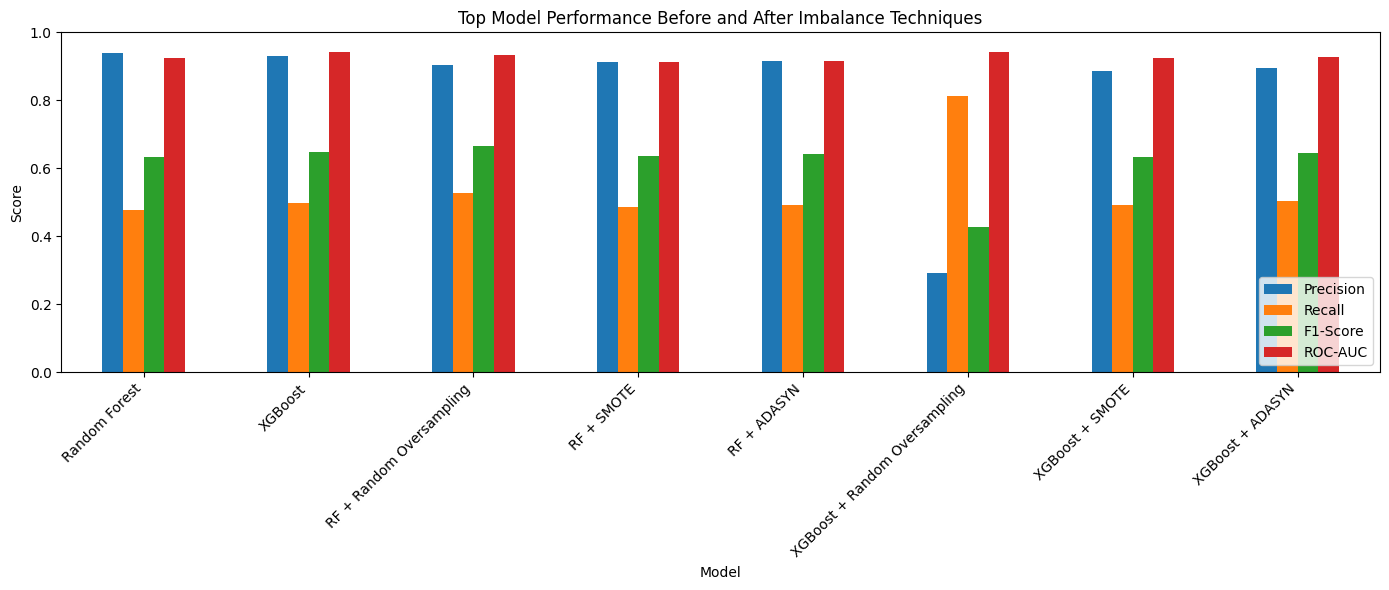

In [ ]:
# Bar Plot Comparison of Metrics

comparison_results.set_index("Model")[["Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Top Model Performance Before and After Imbalance Techniques")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Updated Visualization Block (Correct Colors)**

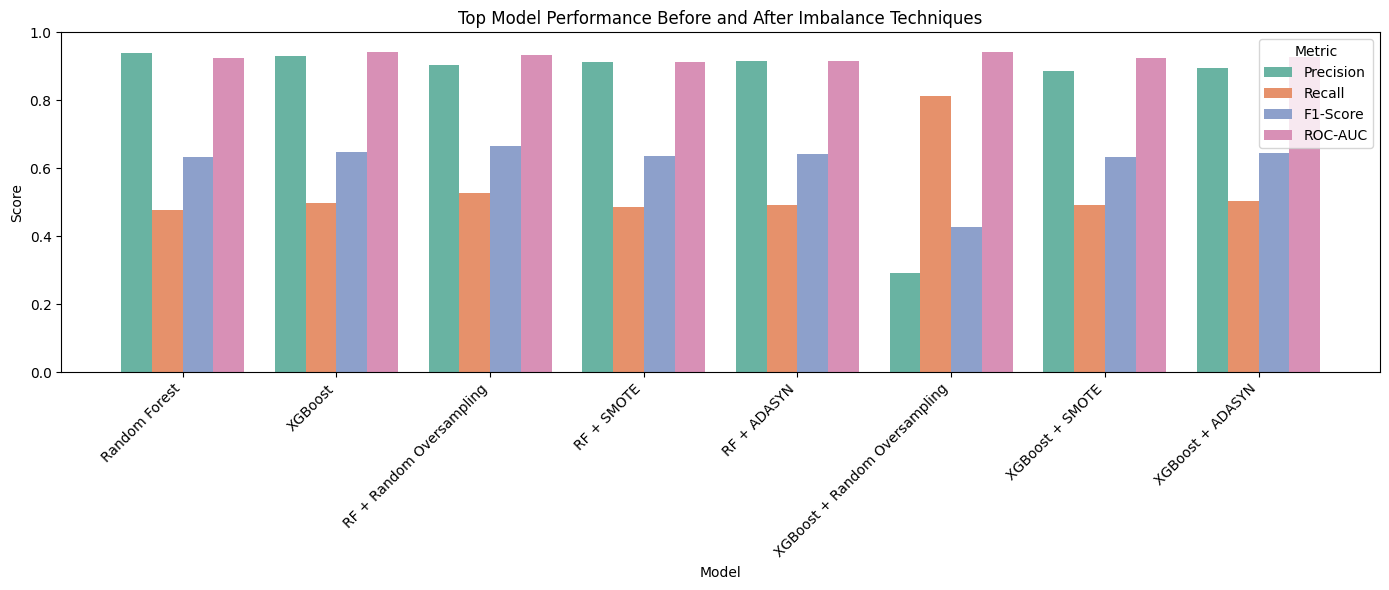

In [ ]:
import numpy as np

# Step 15 – Visualization with consistent presentation colors

metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC"]

colors = {
    "Precision": "#69b3a2",
    "Recall": "#e6916b",
    "F1-Score": "#8da0cb",
    "ROC-AUC": "#d890b6"
}

models = comparison_results["Model"]
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(14,6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        comparison_results[metric],
        width,
        label=metric,
        color=colors[metric]
    )

plt.xticks(x + width*1.5, models, rotation=45, ha="right")
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Top Model Performance Before and After Imbalance Techniques")
plt.ylim(0,1)

plt.legend(title="Metric")
plt.tight_layout()
plt.show()

**Block 4 — ROC curves for all updated top models**

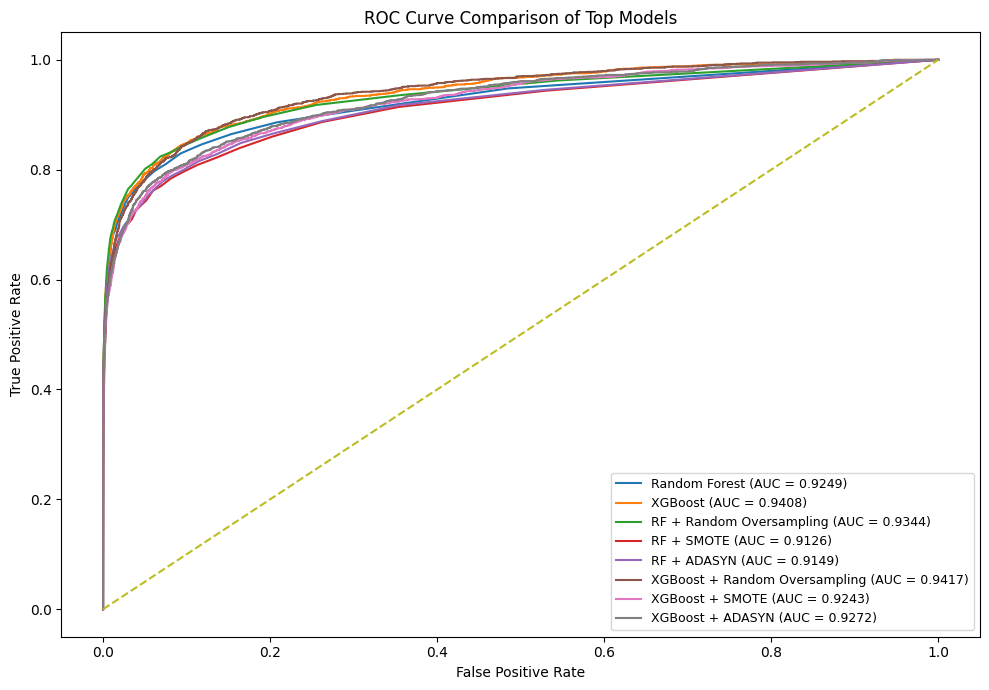

In [ ]:
# ROC Curve Comparison for Top Models

plt.figure(figsize=(10, 7))

# Before imbalance techniques
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.4f})")

# After imbalance techniques
fpr_rf_ros, tpr_rf_ros, _ = roc_curve(y_test, y_prob_rf_ros)
plt.plot(fpr_rf_ros, tpr_rf_ros, label=f"RF + Random Oversampling (AUC = {roc_auc_score(y_test, y_prob_rf_ros):.4f})")

fpr_rf_smote, tpr_rf_smote, _ = roc_curve(y_test, y_prob_rf_smote)
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f"RF + SMOTE (AUC = {roc_auc_score(y_test, y_prob_rf_smote):.4f})")

fpr_rf_adasyn, tpr_rf_adasyn, _ = roc_curve(y_test, y_prob_rf_adasyn)
plt.plot(fpr_rf_adasyn, tpr_rf_adasyn, label=f"RF + ADASYN (AUC = {roc_auc_score(y_test, y_prob_rf_adasyn):.4f})")

fpr_xgb_ros, tpr_xgb_ros, _ = roc_curve(y_test, y_prob_xgb_ros)
plt.plot(fpr_xgb_ros, tpr_xgb_ros, label=f"XGBoost + Random Oversampling (AUC = {roc_auc_score(y_test, y_prob_xgb_ros):.4f})")

fpr_xgb_smote, tpr_xgb_smote, _ = roc_curve(y_test, y_prob_xgb_smote)
plt.plot(fpr_xgb_smote, tpr_xgb_smote, label=f"XGBoost + SMOTE (AUC = {roc_auc_score(y_test, y_prob_xgb_smote):.4f})")

fpr_xgb_adasyn, tpr_xgb_adasyn, _ = roc_curve(y_test, y_prob_xgb_adasyn)
plt.plot(fpr_xgb_adasyn, tpr_xgb_adasyn, label=f"XGBoost + ADASYN (AUC = {roc_auc_score(y_test, y_prob_xgb_adasyn):.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison of Top Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Block 5 — Sort the table by best F1-score**

In [ ]:
# Sort Models by F1-Score

comparison_results_sorted = comparison_results.sort_values(by="F1-Score", ascending=False)

print("Top Models Ranked by F1-Score:\n")
print(comparison_results_sorted.round(4))

Top Models Ranked by F1-Score:

                           Model  Precision  Recall  F1-Score  ROC-AUC
2       RF + Random Oversampling     0.9039  0.5281    0.6667   0.9344
1                        XGBoost     0.9296  0.4985    0.6490   0.9408
7               XGBoost + ADASYN     0.8947  0.5031    0.6440   0.9272
4                    RF + ADASYN     0.9165  0.4929    0.6410   0.9149
3                     RF + SMOTE     0.9137  0.4862    0.6347   0.9126
0                  Random Forest     0.9398  0.4781    0.6338   0.9249
6                XGBoost + SMOTE     0.8853  0.4923    0.6328   0.9243
5  XGBoost + Random Oversampling     0.2902  0.8112    0.4275   0.9417


**Block 6 — Sort the table by best Recall**

In [ ]:
# Sort Models by Recall

comparison_results_recall = comparison_results.sort_values(by="Recall", ascending=False)

print("Top Models Ranked by Recall:\n")
print(comparison_results_recall.round(4))

Top Models Ranked by Recall:

                           Model  Precision  Recall  F1-Score  ROC-AUC
5  XGBoost + Random Oversampling     0.2902  0.8112    0.4275   0.9417
2       RF + Random Oversampling     0.9039  0.5281    0.6667   0.9344
7               XGBoost + ADASYN     0.8947  0.5031    0.6440   0.9272
1                        XGBoost     0.9296  0.4985    0.6490   0.9408
4                    RF + ADASYN     0.9165  0.4929    0.6410   0.9149
6                XGBoost + SMOTE     0.8853  0.4923    0.6328   0.9243
3                     RF + SMOTE     0.9137  0.4862    0.6347   0.9126
0                  Random Forest     0.9398  0.4781    0.6338   0.9249


**Block 7 — Best model row only**

In [ ]:
# Best Model Based on F1-Score

best_model = comparison_results.sort_values(by="F1-Score", ascending=False).head(1)

print("Best Model Based on F1-Score:\n")
print(best_model.round(4))

Best Model Based on F1-Score:

                      Model  Precision  Recall  F1-Score  ROC-AUC
2  RF + Random Oversampling     0.9039  0.5281    0.6667   0.9344


# Explainable Ai ( XAI )

**Global Model Interpretation — Random Forest Feature Importance**

/tmp/ipykernel_7100/4280907800.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


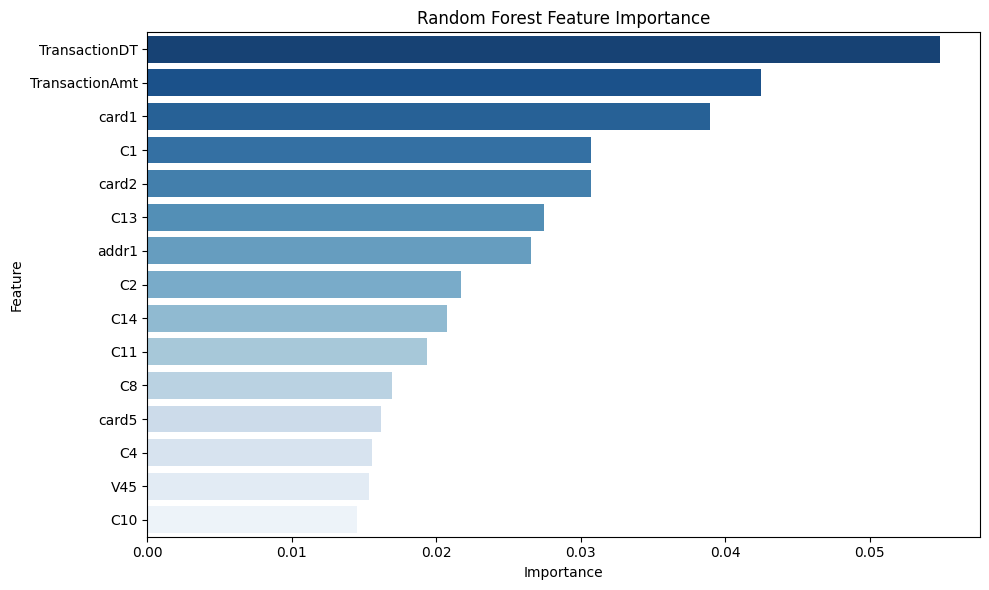

Top 15 Random Forest Features:


,Feature,Importance
0,TransactionDT,0.054890
1,TransactionAmt,0.042484
2,card1,0.038975
9,C1,0.030730
3,card2,0.030708
21,C13,0.027476
6,addr1,0.026573
10,C2,0.021679
22,C14,0.020758
19,C11,0.019378


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 15 Random Forest Features:")
display(rf_importance)

**Global Model Interpretation — XGBoost Feature Importance**

/tmp/ipykernel_7100/1555112747.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


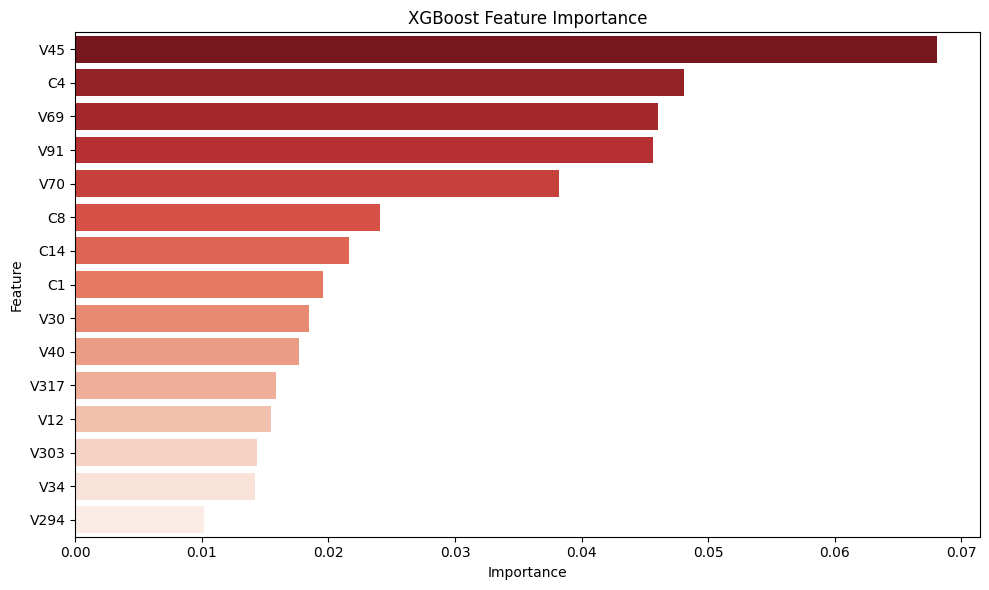

Top 15 XGBoost Features:


,Feature,Importance
75,V45,0.068072
12,C4,0.048078
99,V69,0.046012
121,V91,0.045646
100,V70,0.038187
16,C8,0.024084
22,C14,0.021621
9,C1,0.019585
60,V30,0.018450
70,V40,0.017647


In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=xgb_importance,
    x="Importance",
    y="Feature",
    palette="Reds_r"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 15 XGBoost Features:")
display(xgb_importance)

**Comparison of Top Features from Random Forest and XGBoost**

In [ ]:
top_features_compare = pd.DataFrame({
    "Random Forest Top Features": rf_importance["Feature"].values,
    "XGBoost Top Features": xgb_importance["Feature"].values
})

print("Top Features Comparison:")
display(top_features_compare)

Top Features Comparison:


,Random Forest Top Features,XGBoost Top Features
0,TransactionDT,V45
1,TransactionAmt,C4
2,card1,V69
3,C1,V91
4,card2,V70
5,C13,C8
6,addr1,C14
7,C2,C1
8,C14,V30
9,C11,V40


**Local Model Interpretation — SHAP Setup for XGBoost**

In [ ]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test.iloc[:200])   # smaller slice for speed

print("SHAP values created successfully.")

SHAP values created successfully.


**Local Model Interpretation — SHAP Summary Plot**

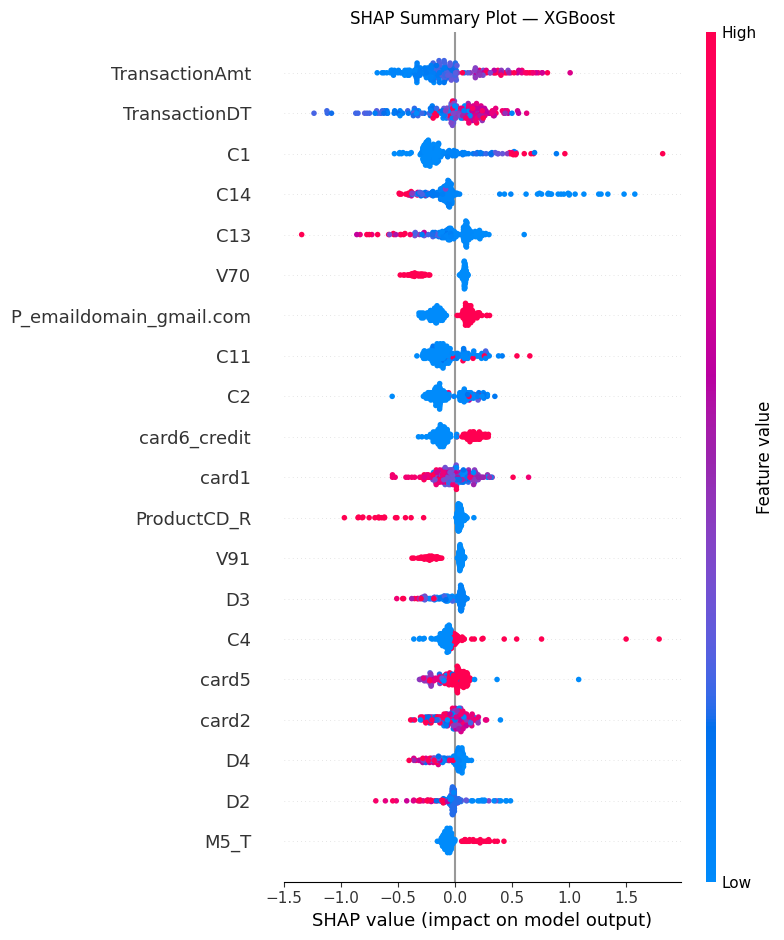

In [ ]:
shap.summary_plot(
    shap_values,
    X_test.iloc[:200],
    show=False
)

plt.title("SHAP Summary Plot — XGBoost")
plt.tight_layout()
plt.show()

**Local Model Interpretation — SHAP Waterfall Plot**

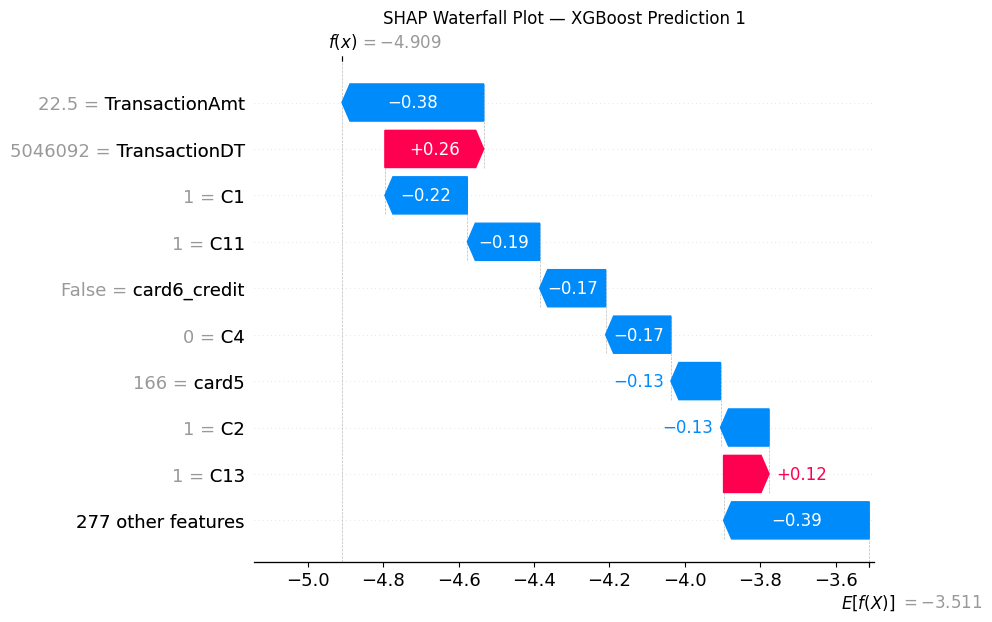

In [ ]:
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Waterfall Plot — XGBoost Prediction 1")
plt.show()

| Feature | Description |
|--------|-------------|
| TransactionAmt | Transaction amount for the purchase. |
| TransactionDT | Time of the transaction in seconds from the start of the dataset recording. |
| card1 | Primary payment card identifier. |
| card2 | Additional payment card identifier. |
| card3 | Card-related category or region code. |
| card4 | Card network such as Visa, Mastercard, American Express, or Discover. |
| card5 | Card issuing bank or card category identifier. |
| card6 | Type of card such as credit or debit. |
| card6_credit | Indicator that the transaction used a credit card. |
| addr1 | Billing region or address-based numerical code. |
| addr2 | Additional billing address or country-related code. |
| dist1 | Distance between billing and shipping location or another location-based measure. |
| dist2 | Second anonymized distance-related feature. |
| C1 | Count of related transactions over a recent period. |
| C2 | Count-based feature related to transaction frequency. |
| C4 | Aggregated count feature linked to transaction behavior. |
| C5 | Historical count feature related to prior account or card usage. |
| C6 | Count-based behavioral feature derived from previous transactions. |
| C7 | Aggregated transaction count feature. |
| C8 | Aggregated transaction count feature. |
| C9 | Historical count feature reflecting prior transaction activity. |
| C10 | Count feature summarizing related account behavior. |
| C11 | Aggregated count feature showing previous transaction behavior. |
| C12 | Historical count feature associated with transaction patterns. |
| C13 | Historical count feature linked to account or card activity. |
| C14 | Aggregated behavioral feature from previous transactions. |
| D1 | Time delta feature showing days since a related transaction. |
| D2 | Time-related feature measuring delay from a previous event. |
| D3 | Time difference between related transactions or events. |
| D4 | Time-related delay feature between account activities. |
| D5 | Additional time-based transaction delay feature. |
| D10 | Time-based feature derived from earlier activity. |
| D11 | Historical timing feature related to previous events. |
| D15 | Time difference feature useful for fraud pattern detection. |
| V70 | Engineered anonymized feature derived from transaction behavior. |
| V86 | Anonymized engineered variable capturing statistical transaction patterns. |
| V91 | Derived feature that captures statistical behavior patterns. |
| V127 | Engineered anonymized variable related to transaction characteristics. |
| V130 | Anonymized behavioral feature derived from internal transaction statistics. |
| V138 | Engineered statistical feature related to customer or transaction activity. |
| V156 | Anonymized variable representing hidden transaction behavior patterns. |
| V187 | Derived transaction feature created from internal statistical relationships. |
| V201 | Engineered anonymized feature useful for distinguishing fraud behavior. |
| V203 | Statistical feature capturing hidden transaction-level patterns. |
| M4 | Match-status feature related to account or transaction verification. |
| M5 | Match-status feature representing a yes/no verification condition. |
| M5_T | Binary indicator for a specific verification match condition. |
| M6 | Verification or matching feature related to account consistency. |
| ProductCD | Product category code for the transaction. |
| P_emaildomain | Purchaser email domain. |
| P_emaildomain_gmail.com | Indicator that the purchaser email domain is Gmail. |
| R_emaildomain | Recipient email domain. |
| DeviceType | Type of device used in the transaction, such as desktop or mobile. |
| DeviceInfo | Device information string describing browser, OS, or hardware. |
| id_01 | Identity-related anonymized feature from the identity dataset. |
| id_02 | Numeric identity-related feature associated with the user or transaction. |
| id_19 | Anonymized identity feature derived from account information. |
| id_20 | Identity-related numerical feature linked to device or account patterns. |

## XAI Interpretation

The feature importance plots from Random Forest and XGBoost show which variables contributed the most to fraud prediction at the global level. Features such as TransactionAmt, TransactionDT, card-based variables, count features, and time-difference features had strong influence in both models.

The SHAP summary plot provides a broader view of how feature values affect predictions across many transactions. It shows both the magnitude and direction of each feature’s impact on fraud classification.

The SHAP waterfall plot explains one individual prediction by showing how each feature pushed the model toward fraud or non-fraud. The SHAP force plot gives another local explanation in a more visual format.

Together, these XAI methods improve transparency by helping explain why the model made its predictions, which is especially important in fraud detection where interpretability supports trust and decision-making.

# **Last Implementations**

Starting shape: (292590, 222)
Dropped very sparse columns (>95% missing): 0
Train shape: (234072, 228)
Test shape : (58518, 228)


/tmp/ipykernel_7100/3298750735.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_raw[f"{col}_freq"] = X_train_raw[col].astype(str).map(freq_map).fillna(0)
/tmp/ipykernel_7100/3298750735.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_raw[f"{col}_freq"] = X_test_raw[col].astype(str).map(freq_map).fillna(0)
/tmp/ipykernel_7100/3298750735.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining

Encoded train shape: (234072, 296)
Encoded test shape : (58518, 296)
Dropped highly correlated columns (>0.98): 20
Shape after correlation filter: (234072, 276)
scale_pos_weight: 28.86
Selected top 100 features using XGBoost importance.

Chosen threshold: 0.5500000000000002
threshold    0.550000
precision    0.354106
recall       0.803061
f1           0.491491
Name: 9, dtype: float64

========== FINAL XGBOOST RESULTS ==========
ROC-AUC: 0.9482
Average Precision: 0.7075

Classification Report:

              precision    recall  f1-score   support

           0     0.9929    0.9492    0.9706     56558
           1     0.3541    0.8031    0.4915      1960

    accuracy                         0.9443     58518
   macro avg     0.6735    0.8761    0.7310     58518
weighted avg     0.9715    0.9443    0.9545     58518

5-Fold CV Recall: [0.8055 0.8182 0.8092 0.8227 0.8138]
Mean CV Recall   : 0.8139
5-Fold CV ROC-AUC: [0.944  0.9456 0.9499 0.9508 0.9474]
Mean CV ROC-AUC  : 0.9475

==========

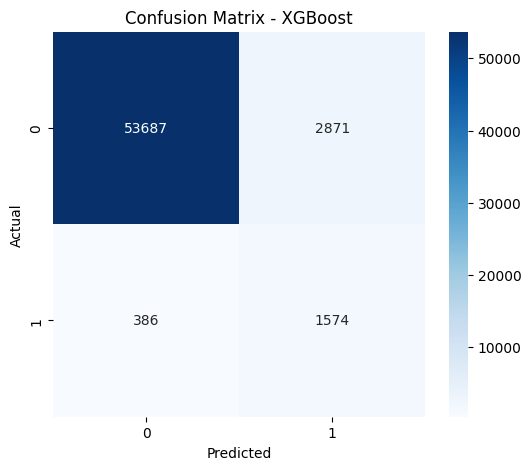

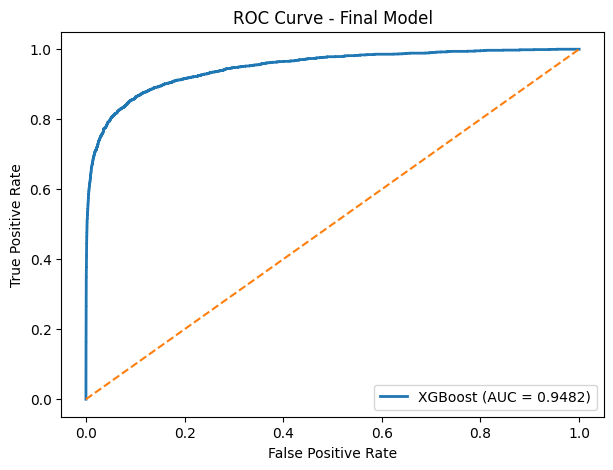

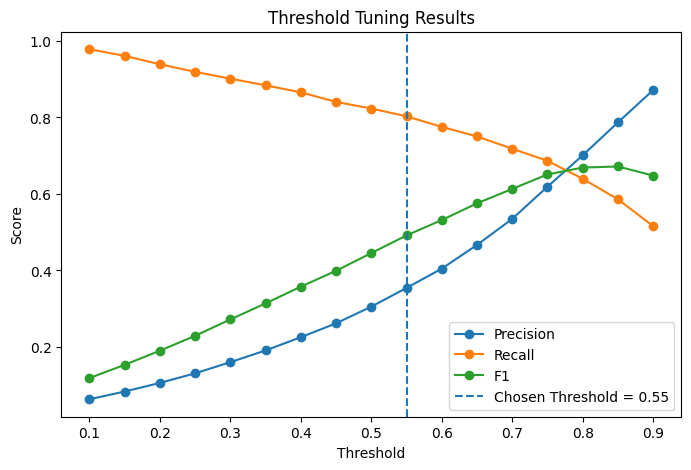

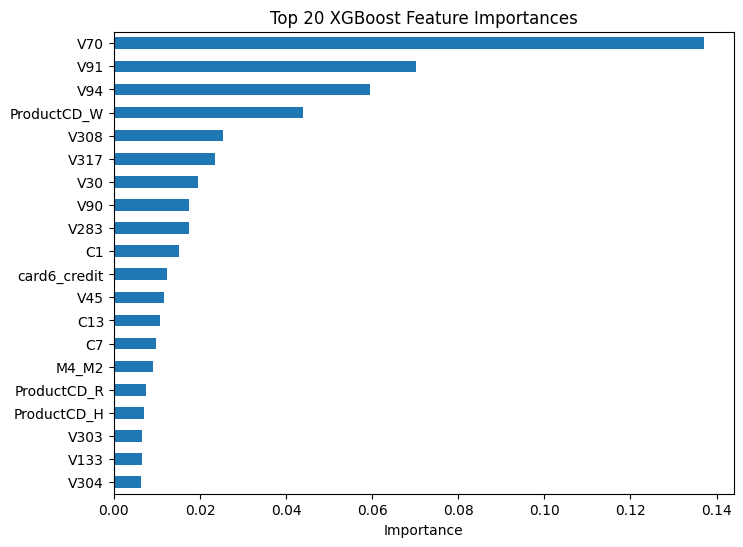


========== FINAL SUMMARY TABLE ==========
      Model  ROC-AUC  Recall_Class_1  F1_Class_1  Threshold_Used
0   XGBoost   0.9482          0.8031      0.4915            0.55
1  Ensemble   0.9393          0.7694      0.5031            0.55

INTERPRETATION:

This final implementation improved the fraud detection pipeline by adding feature engineering,
removing weak or redundant features, using XGBoost for model-based feature selection,
and tuning the classification threshold to prioritize fraud recall.

The final selected model was: XGBoost.
Its ROC-AUC was 0.9482, and the threshold was adjusted to 0.55
to improve detection of fraud cases instead of relying on the default 0.50 cutoff.

Stratified 5-fold cross-validation was used to check model stability because leave-one-out
cross-validation would be too expensive and unnecessary for a dataset this large.
Overall, these steps made the model more focused on the minority fraud class and better aligned
with the business goal of catching as m

In [ ]:
# =========================
# LAST IMPLEMENTATIONS
# Final improved fraud pipeline
# =========================

# -------------------------
# 1. Imports
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

# -------------------------
# 2. Start from your cleaned dataset
#    Assumes "data" already exists from your earlier notebook steps
# -------------------------
final_data = data.copy()

print("Starting shape:", final_data.shape)

# -------------------------
# 3. Basic cleanup
#    Remove columns we do not want the model to learn from directly
# -------------------------
drop_cols = ["TransactionID", "AmountBin"]
final_data = final_data.drop(columns=[c for c in drop_cols if c in final_data.columns], errors="ignore")

# -------------------------
# 4. Feature Engineering
# -------------------------

# 4.1 Missing count per row
# Why: fraud can sometimes be associated with incomplete identity/device information
final_data["missing_count"] = final_data.isnull().sum(axis=1)

# 4.2 Log transform transaction amount
# Why: transaction amounts are usually skewed, and log helps compress very large values
if "TransactionAmt" in final_data.columns:
    final_data["log_TransactionAmt"] = np.log1p(final_data["TransactionAmt"])

# 4.3 Email match feature
# Why: mismatched purchaser/recipient email domains may carry fraud signal
if "P_emaildomain" in final_data.columns and "R_emaildomain" in final_data.columns:
    final_data["email_domain_match"] = (
        final_data["P_emaildomain"].fillna("missing") ==
        final_data["R_emaildomain"].fillna("missing")
    ).astype(int)

# 4.4 Missing indicators for useful high-missing columns
# Why: whether a value is missing can itself be predictive
candidate_missing_cols = [
    "DeviceType", "DeviceInfo", "id_30", "id_31", "id_33",
    "card4", "card6", "addr1", "addr2", "P_emaildomain", "R_emaildomain"
]
for col in candidate_missing_cols:
    if col in final_data.columns:
        final_data[f"{col}_missing_flag"] = final_data[col].isnull().astype(int)

# -------------------------
# 5. Remove extremely sparse columns
#    Why: these features often add noise and little usable signal
# -------------------------
missing_ratio = final_data.isnull().mean()
very_sparse_cols = missing_ratio[missing_ratio > 0.95].index.tolist()

# never remove target if it appears by accident
very_sparse_cols = [c for c in very_sparse_cols if c != "isFraud"]

final_data = final_data.drop(columns=very_sparse_cols, errors="ignore")
print("Dropped very sparse columns (>95% missing):", len(very_sparse_cols))

# -------------------------
# 6. Fill remaining missing values
#    Why: XGBoost can handle missing values, but after feature engineering and encoding,
#    it is safer to make the matrix clean and consistent
# -------------------------
for col in final_data.columns:
    if col == "isFraud":
        continue
    if final_data[col].dtype == "object":
        final_data[col] = final_data[col].fillna("missing")
    else:
        final_data[col] = final_data[col].fillna(final_data[col].median())

# -------------------------
# 7. Split features and target
# -------------------------
X = final_data.drop("isFraud", axis=1)
y = final_data["isFraud"]

# -------------------------
# 8. Train-test split
#    Why: stratify keeps the fraud ratio similar in both sets
# -------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train_raw.shape)
print("Test shape :", X_test_raw.shape)

# -------------------------
# 9. Frequency encoding for a few high-cardinality columns
#    Why: helps capture how common/rare values are
#    IMPORTANT: fit on train only to avoid leakage
# -------------------------
freq_cols = ["card1", "addr1", "P_emaildomain", "R_emaildomain", "DeviceInfo"]
for col in freq_cols:
    if col in X_train_raw.columns:
        freq_map = X_train_raw[col].astype(str).value_counts(dropna=False).to_dict()
        X_train_raw[f"{col}_freq"] = X_train_raw[col].astype(str).map(freq_map).fillna(0)
        X_test_raw[f"{col}_freq"] = X_test_raw[col].astype(str).map(freq_map).fillna(0)

# -------------------------
# 10. One-hot encode train and test separately, then align columns
#     Why: avoids train/test leakage better than encoding full data before split
# -------------------------
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test = pd.get_dummies(X_test_raw, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoded train shape:", X_train.shape)
print("Encoded test shape :", X_test.shape)

# -------------------------
# 11. Remove highly correlated numeric features
#     Why: reduces redundancy and can simplify the model
# -------------------------
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.98)]

X_train = X_train.drop(columns=high_corr_cols, errors="ignore")
X_test = X_test.drop(columns=high_corr_cols, errors="ignore")

print("Dropped highly correlated columns (>0.98):", len(high_corr_cols))
print("Shape after correlation filter:", X_train.shape)

# -------------------------
# 12. Handle imbalance using class weighting
#     Why: fraud is rare, so we tell XGBoost to care more about the minority class
# -------------------------
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("scale_pos_weight:", round(scale_pos_weight_value, 2))

# -------------------------
# 13. First XGBoost model
#     Why: tree boosting is usually very strong on high-dimensional tabular data
# -------------------------
xgb_base = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_jobs=-1
)

xgb_base.fit(X_train, y_train)

# -------------------------
# 14. Model-based feature selection using XGBoost importance
#     Why: professor recommended model-based feature selection instead of PCA
# -------------------------
feature_importance = pd.Series(
    xgb_base.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_k = 100 if X_train.shape[1] > 100 else X_train.shape[1]
top_features = feature_importance.head(top_k).index.tolist()

X_train_top = X_train[top_features].copy()
X_test_top = X_test[top_features].copy()

print(f"Selected top {len(top_features)} features using XGBoost importance.")

# -------------------------
# 15. Retrain XGBoost on selected features
#     Why: stronger signal, less noise, easier interpretation
# -------------------------
xgb_final = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(X_train_top, y_train)

# -------------------------
# 16. Predicted probabilities
# -------------------------
y_prob = xgb_final.predict_proba(X_test_top)[:, 1]

# -------------------------
# 17. Threshold tuning
#     Why: default 0.50 is often not best for fraud recall
#     Goal: push recall for class 1 higher
# -------------------------
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

# Try to meet recall >= 0.80 if possible
target_recall = 0.80
candidate_df = threshold_df[threshold_df["recall"] >= target_recall].copy()

if len(candidate_df) > 0:
    best_row = candidate_df.sort_values(["f1", "precision"], ascending=False).iloc[0]
else:
    # if 0.80 recall is not reached, choose the threshold with best F1
    best_row = threshold_df.sort_values(["f1", "recall"], ascending=False).iloc[0]

best_threshold = float(best_row["threshold"])
print("\nChosen threshold:", best_threshold)
print(best_row)

# Final predictions using tuned threshold
y_pred_final = (y_prob >= best_threshold).astype(int)

# -------------------------
# 18. Final evaluation
# -------------------------
final_auc = roc_auc_score(y_test, y_prob)
final_ap = average_precision_score(y_test, y_prob)
final_cm = confusion_matrix(y_test, y_pred_final)

print("\n========== FINAL XGBOOST RESULTS ==========")
print("ROC-AUC:", round(final_auc, 4))
print("Average Precision:", round(final_ap, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, digits=4))

# -------------------------
# 19. Stratified 5-Fold Cross-Validation
#     Why: better than leave-one-out for a dataset this large and imbalanced
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    xgb_final,
    X_train_top,
    y_train,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

cv_auc = cross_val_score(
    xgb_final,
    X_train_top,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold CV Recall:", np.round(cv_recall, 4))
print("Mean CV Recall   :", round(cv_recall.mean(), 4))
print("5-Fold CV ROC-AUC:", np.round(cv_auc, 4))
print("Mean CV ROC-AUC  :", round(cv_auc.mean(), 4))

# -------------------------
# 20. Optional Ensemble
#     Why: combining strong tree models can sometimes improve stability
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_final),
        ("rf", rf_model)
    ],
    voting="soft",
    n_jobs=-1
)

ensemble_model.fit(X_train_top, y_train)
ensemble_prob = ensemble_model.predict_proba(X_test_top)[:, 1]
ensemble_pred = (ensemble_prob >= best_threshold).astype(int)

ensemble_auc = roc_auc_score(y_test, ensemble_prob)
ensemble_recall = recall_score(y_test, ensemble_pred)
ensemble_f1 = f1_score(y_test, ensemble_pred)

print("\n========== OPTIONAL ENSEMBLE RESULTS ==========")
print("Ensemble ROC-AUC:", round(ensemble_auc, 4))
print("Ensemble Recall :", round(ensemble_recall, 4))
print("Ensemble F1     :", round(ensemble_f1, 4))

# -------------------------
# 21. Decide best final model
# -------------------------
xgb_recall = recall_score(y_test, y_pred_final)
xgb_f1 = f1_score(y_test, y_pred_final)

if (ensemble_recall > xgb_recall) or ((ensemble_recall == xgb_recall) and (ensemble_f1 > xgb_f1)):
    best_model_name = "Ensemble (XGBoost + Random Forest)"
    best_prob = ensemble_prob
    best_pred = ensemble_pred
    best_auc = ensemble_auc
else:
    best_model_name = "XGBoost"
    best_prob = y_prob
    best_pred = y_pred_final
    best_auc = final_auc

print(f"\nBest final model selected: {best_model_name}")

# -------------------------
# 22. Plots
# -------------------------

# 22.1 Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 22.2 ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"{best_model_name} (AUC = {best_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Final Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 22.3 Precision / Recall vs Threshold
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.axvline(best_threshold, linestyle="--", label=f"Chosen Threshold = {best_threshold:.2f}")
plt.title("Threshold Tuning Results")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# 22.4 Top 20 Feature Importances
top_20 = feature_importance.head(20).sort_values()
plt.figure(figsize=(8, 6))
top_20.plot(kind="barh")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

# -------------------------
# 23. Final summary table
# -------------------------
summary_table = pd.DataFrame({
    "Model": ["XGBoost", "Ensemble"],
    "ROC-AUC": [
        round(final_auc, 4),
        round(ensemble_auc, 4)
    ],
    "Recall_Class_1": [
        round(xgb_recall, 4),
        round(ensemble_recall, 4)
    ],
    "F1_Class_1": [
        round(xgb_f1, 4),
        round(ensemble_f1, 4)
    ],
    "Threshold_Used": [best_threshold, best_threshold]
})

print("\n========== FINAL SUMMARY TABLE ==========")
print(summary_table)

# -------------------------
# 24. Easy interpretation text for your notebook
# -------------------------
print("\nINTERPRETATION:")
print(f"""
This final implementation improved the fraud detection pipeline by adding feature engineering,
removing weak or redundant features, using XGBoost for model-based feature selection,
and tuning the classification threshold to prioritize fraud recall.

The final selected model was: {best_model_name}.
Its ROC-AUC was {best_auc:.4f}, and the threshold was adjusted to {best_threshold:.2f}
to improve detection of fraud cases instead of relying on the default 0.50 cutoff.

Stratified 5-fold cross-validation was used to check model stability because leave-one-out
cross-validation would be too expensive and unnecessary for a dataset this large.
Overall, these steps made the model more focused on the minority fraud class and better aligned
with the business goal of catching as many fraudulent transactions as possible.
""")

#**Deployment**

In [ ]:
import joblib

joblib.dump(xgb_final, "xgb_fraud_model.pkl")
joblib.dump(top_features, "model_features.pkl")

print("Saved!")

Saved!


**Getting Numbers to Input**

In [ ]:
app_features = ["TransactionAmt", "card1", "C1", "C7", "C13", "V70", "V91", "V94", "V30"]

y_prob_demo = xgb_final.predict_proba(X_test_top)[:, 1]
y_pred_demo = (y_prob_demo >= 0.50).astype(int)

demo_df = X_test_top.copy()
demo_df["pred"] = y_pred_demo
demo_df["prob_fraud"] = y_prob_demo
demo_df["actual"] = y_test.values

available_app_features = [c for c in app_features if c in demo_df.columns]

fraud_example = demo_df.sort_values("prob_fraud", ascending=False)
fraud_example = fraud_example[fraud_example["pred"] == 1].iloc[0]

notfraud_example = demo_df.sort_values("prob_fraud", ascending=True)
notfraud_example = notfraud_example[notfraud_example["pred"] == 0].iloc[0]

print("\n=== HIGH-CONFIDENCE FRAUD EXAMPLE ===")
for col in available_app_features:
    print(f"{col} = {fraud_example[col]}")
print(f"Predicted class = {fraud_example['pred']}")
print(f"Fraud probability = {fraud_example['prob_fraud']:.4f}")
print(f"Actual class = {fraud_example['actual']}")

print("\n=== HIGH-CONFIDENCE NOT FRAUD EXAMPLE ===")
for col in available_app_features:
    print(f"{col} = {notfraud_example[col]}")
print(f"Predicted class = {notfraud_example['pred']}")
print(f"Fraud probability = {notfraud_example['prob_fraud']:.4f}")
print(f"Actual class = {notfraud_example['actual']}")


=== HIGH-CONFIDENCE FRAUD EXAMPLE ===
TransactionAmt = 24.836
card1 = 10369
C1 = 50.0
C7 = 13.0
C13 = 1.0
V70 = 0.0
V91 = 0.0
V94 = 1.0
V30 = 0.0
Predicted class = 1
Fraud probability = 0.9996
Actual class = 1

=== HIGH-CONFIDENCE NOT FRAUD EXAMPLE ===
TransactionAmt = 35.95
card1 = 1702
C1 = 1.0
C7 = 0.0
C13 = 33.0
V70 = 1.0
V91 = 1.0
V94 = 0.0
V30 = 1.0
Predicted class = 0
Fraud probability = 0.0006
Actual class = 0


In [ ]:
app_features = ["TransactionAmt", "card1", "C1", "C7", "C13", "V70", "V91", "V94", "V30"]

demo_df = X_test_top.copy()
demo_df["prob_fraud"] = xgb_final.predict_proba(X_test_top)[:, 1]
demo_df["pred"] = (demo_df["prob_fraud"] >= 0.5).astype(int)
demo_df["actual"] = y_test.values

# keep only rows predicted as fraud
fraud_rows = demo_df[demo_df["pred"] == 1].copy()

# sort by highest fraud probability
fraud_rows = fraud_rows.sort_values("prob_fraud", ascending=False)

best_fraud = fraud_rows.iloc[0]

print("=== BEST APP-COMPATIBLE FRAUD EXAMPLE ===")
for col in app_features:
    print(f"{col} = {best_fraud[col]}")
print(f"Predicted class = {best_fraud['pred']}")
print(f"Fraud probability = {best_fraud['prob_fraud']:.4f}")
print(f"Actual class = {best_fraud['actual']}")

=== BEST APP-COMPATIBLE FRAUD EXAMPLE ===
TransactionAmt = 24.836
card1 = 10369
C1 = 50.0
C7 = 13.0
C13 = 1.0
V70 = 0.0
V91 = 0.0
V94 = 1.0
V30 = 0.0
Predicted class = 1
Fraud probability = 0.9996
Actual class = 1


**Deployment Features**

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
import pandas as pd

feature_explanations = pd.DataFrame({
    "Feature": [
        "TransactionAmt", "card1", "addr1", "C1", "C7", "C13",
        "V70", "V91", "V94", "V30"
    ],

    "What it Means (Simple)": [
        "Amount of the transaction in dollars",
        "Anonymized card ID (represents the user's card)",
        "Billing region or location of the transaction",
        "Count of related transactions (activity level)",
        "Pattern of transaction timing or behavior",
        "Number of previous similar transactions",
        "Hidden pattern feature (statistical behavior signal)",
        "Hidden pattern feature (risk-related signal)",
        "Hidden pattern feature (fraud tendency indicator)",
        "Hidden pattern feature (transaction consistency)"
    ],

    "Why it Matters for Fraud Detection": [
        "Unusual amounts can indicate fraud (too high or too low)",
        "Some cards are more associated with fraud patterns",
        "Location mismatches can signal suspicious activity",
        "High activity in short time may indicate fraud",
        "Strange timing patterns can reveal fraud behavior",
        "Repeated patterns may indicate automated fraud",
        "Captures complex hidden behavior not visible directly",
        "Helps model detect subtle fraud patterns",
        "Strong indicator used by model to separate fraud vs normal",
        "Helps identify inconsistency in user behavior"
    ]
})

feature_explanations

,Feature,What it Means (Simple),Why it Matters for Fraud Detection
0,TransactionAmt,Amount of the transaction in dollars,Unusual amounts can indicate fraud (too high or too low)
1,card1,Anonymized card ID (represents the user's card),Some cards are more associated with fraud patterns
2,addr1,Billing region or location of the transaction,Location mismatches can signal suspicious activity
3,C1,Count of related transactions (activity level),High activity in short time may indicate fraud
4,C7,Pattern of transaction timing or behavior,Strange timing patterns can reveal fraud behavior
5,C13,Number of previous similar transactions,Repeated patterns may indicate automated fraud
6,V70,Hidden pattern feature (statistical behavior signal),Captures complex hidden behavior not visible directly
7,V91,Hidden pattern feature (risk-related signal),Helps model detect subtle fraud patterns
8,V94,Hidden pattern feature (fraud tendency indicator),Strong indicator used by model to separate fraud vs normal
9,V30,Hidden pattern feature (transaction consistency),Helps identify inconsistency in user behavior


In [ ]:
from IPython.display import display

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

display(feature_explanations)

,Feature,What it Means (Simple),Why it Matters for Fraud Detection
0,TransactionAmt,Amount of the transaction in dollars,Unusual amounts can indicate fraud (too high or too low)
1,card1,Anonymized card ID (represents the user's card),Some cards are more associated with fraud patterns
2,addr1,Billing region or location of the transaction,Location mismatches can signal suspicious activity
3,C1,Count of related transactions (activity level),High activity in short time may indicate fraud
4,C7,Pattern of transaction timing or behavior,Strange timing patterns can reveal fraud behavior
5,C13,Number of previous similar transactions,Repeated patterns may indicate automated fraud
6,V70,Hidden pattern feature (statistical behavior signal),Captures complex hidden behavior not visible directly
7,V91,Hidden pattern feature (risk-related signal),Helps model detect subtle fraud patterns
8,V94,Hidden pattern feature (fraud tendency indicator),Strong indicator used by model to separate fraud vs normal
9,V30,Hidden pattern feature (transaction consistency),Helps identify inconsistency in user behavior
